# Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from category_encoders.leave_one_out import LeaveOneOutEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
# noinspection PyPackageRequirements
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import normaltest, anderson
from scipy.stats import shapiro
from scipy.stats import spearmanr
import os
import shutil
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from scipy.stats import levene
from sklearn.feature_selection import f_classif

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.impute import SimpleImputer
from category_encoders.leave_one_out import LeaveOneOutEncoder
from sklearn.feature_selection import mutual_info_regression 
from sklearn.base import BaseEstimator, TransformerMixin

import category_encoders as ce
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# Load datasets

In [2]:
# Load datasets
df1 = pd.read_csv("observations2.tsv", sep='\t')
df2 = pd.read_csv("patients2.tsv", sep='\t')
df3 = pd.read_csv("stations2.tsv", sep='\t')

In [3]:
df1.columns.tolist()

['SPO2',
 'HR',
 'PI',
 'RR',
 'ETCO2',
 'FIO2',
 'PRV',
 'BP',
 'ST',
 'MAI',
 'PVI',
 'Hb level',
 'SV',
 'CO',
 'Blood Flow Index',
 'PPG waveform features',
 'Signal Quality Index',
 'Respiratory effort',
 'O₂ extraction ratio',
 'SNR',
 'oximetry',
 'latitude',
 'longitude']

In [4]:
df2.columns.tolist()

['address',
 'job',
 'company',
 'blood_group',
 'ssn',
 'station_ID',
 'current_latitude',
 'current_longitude']

In [5]:
df3.columns.tolist()

['longitude', 'latitude', 'code', 'station', 'location']

In [6]:
result = df2.groupby('station_ID')['blood_group'].value_counts()
print(result)

station_ID  blood_group
0           AB+            1
1           A-             2
            A+             1
            AB+            1
            AB-            1
                          ..
804         AB+            1
            B-             1
805         A-             1
            B-             1
            O+             1
Name: count, Length: 1772, dtype: int64


We are going to join observations with stations because: 
- both dataset contain latitude + longtitude and we know that it can be mapped one to another
- station, code, location may represent different equipment, staff, these may influence the measuremtns

We are not merging df2 with observations because: 
- There is no common identifier
- The only possible link is with stations and it would bring errors
- Label noise if we incorrectly link patient with observation
- Aggregating patient attributes per station is not useful because attributes blood_group, job, company, address are individual specific, not station-level



# Merging df1 with df3

For merging we are using data from eda before applying outlier handling. Cleaned data with no duplicates and unnecessary data

In [7]:
keys = ['longitude', 'latitude']
df = pd.merge(df1, df3, on=keys, how='inner')

In [8]:
df.shape

(12072, 26)

In [9]:
df.columns.tolist()

['SPO2',
 'HR',
 'PI',
 'RR',
 'ETCO2',
 'FIO2',
 'PRV',
 'BP',
 'ST',
 'MAI',
 'PVI',
 'Hb level',
 'SV',
 'CO',
 'Blood Flow Index',
 'PPG waveform features',
 'Signal Quality Index',
 'Respiratory effort',
 'O₂ extraction ratio',
 'SNR',
 'oximetry',
 'latitude',
 'longitude',
 'code',
 'station',
 'location']

In [10]:
df['location'].nunique()

140

In [11]:
df['code'].nunique()

107

In [12]:
df['station'].nunique()

552

Location is other high-cardinality categorical data which we can replace with code and longtitude and latitude
- one hot encoding would increase dimensionality and it would hurt our model, no meaningful geographical location, we already have latitude and longitude

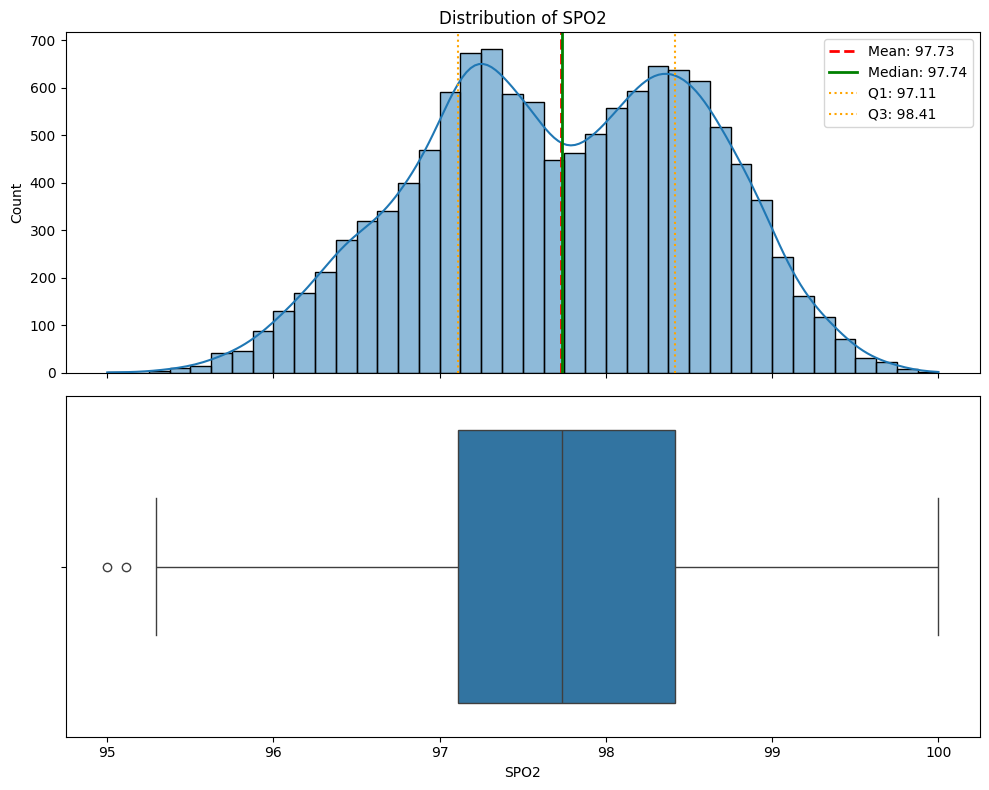


--- SPO2 ---
Probably not normal
------------------------------------------------------------


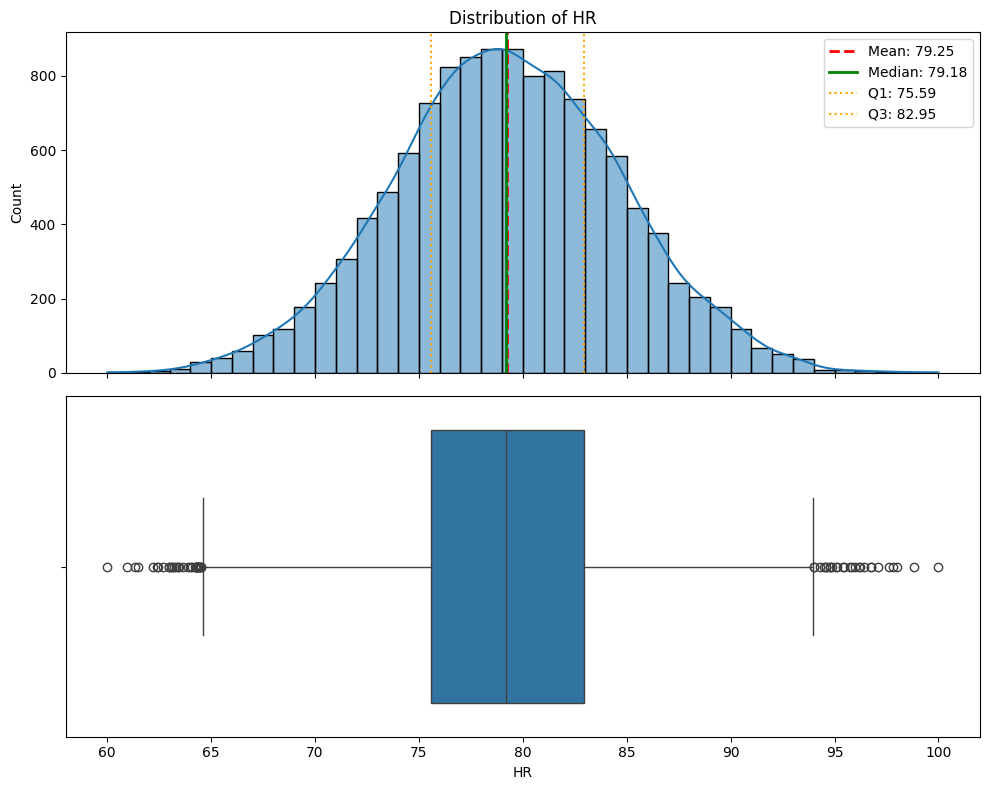


--- HR ---
Probably normal
------------------------------------------------------------


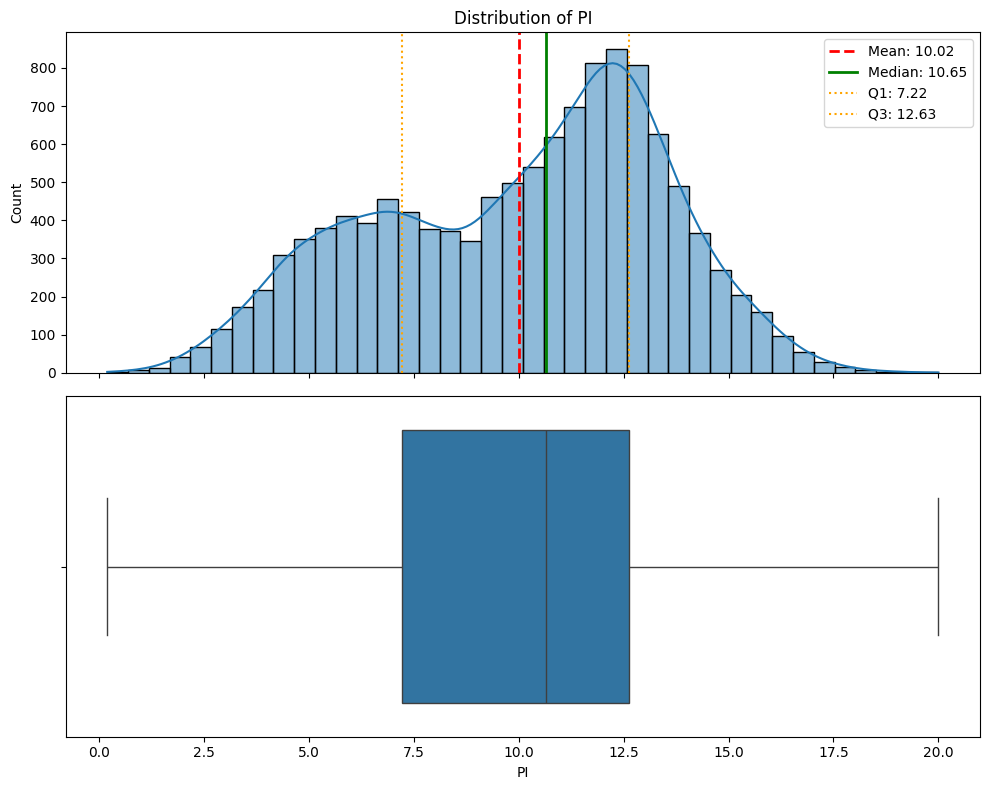


--- PI ---
Probably not normal
------------------------------------------------------------


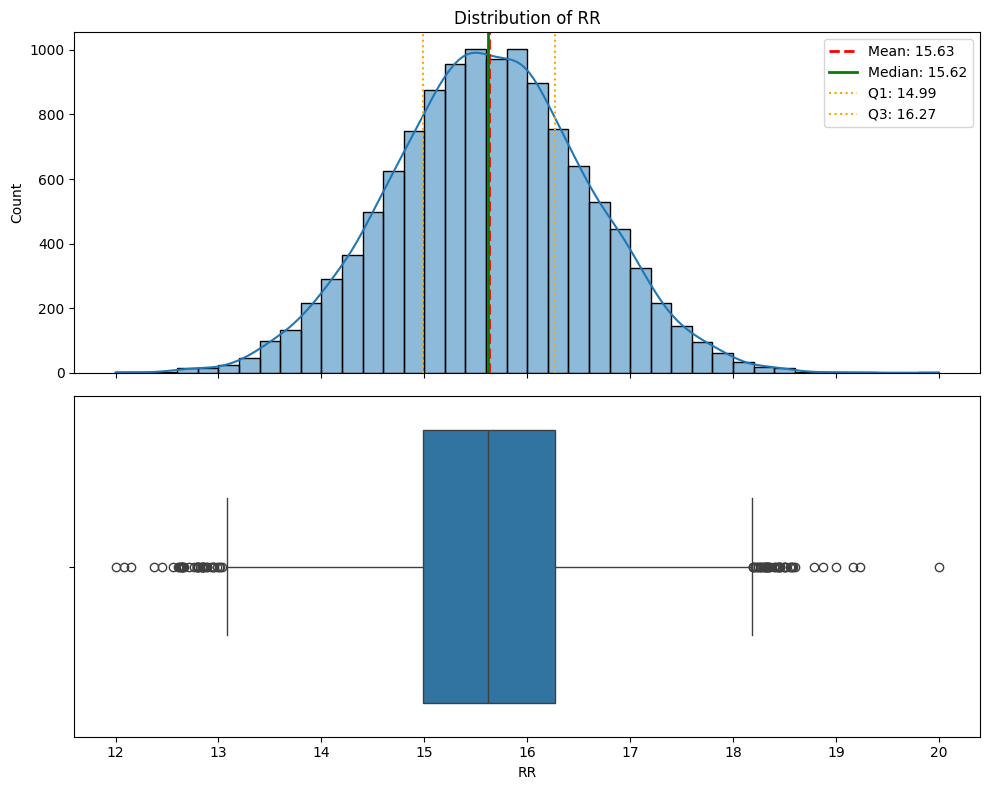


--- RR ---
Probably normal
------------------------------------------------------------


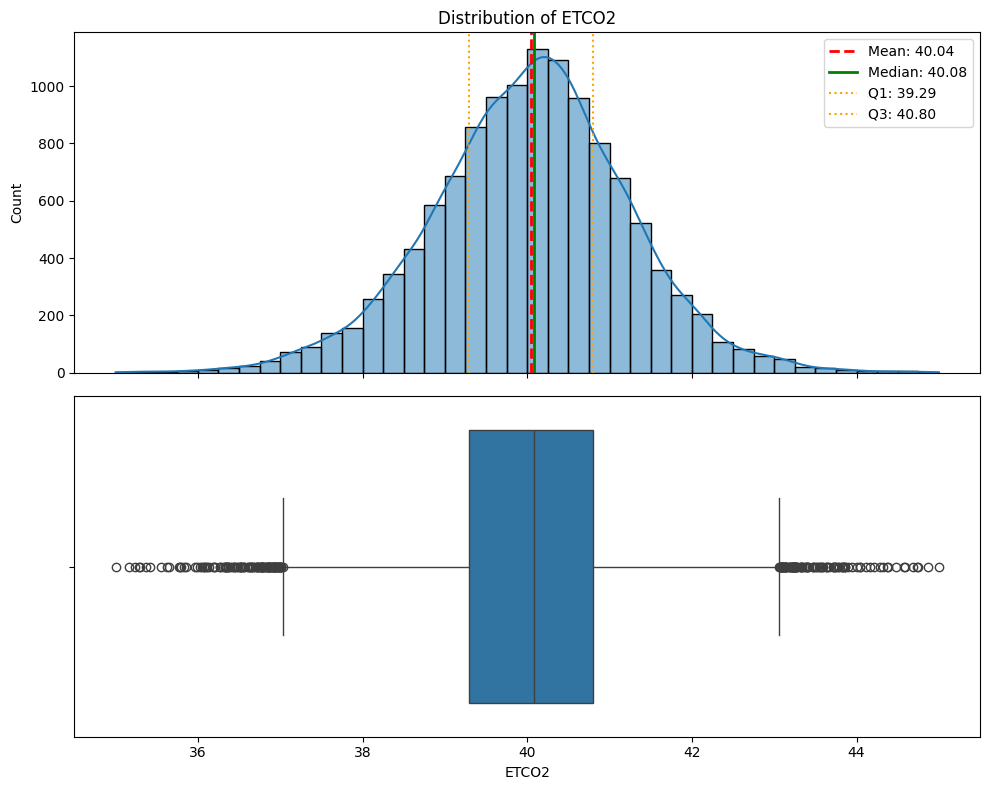


--- ETCO2 ---
Probably not normal
------------------------------------------------------------


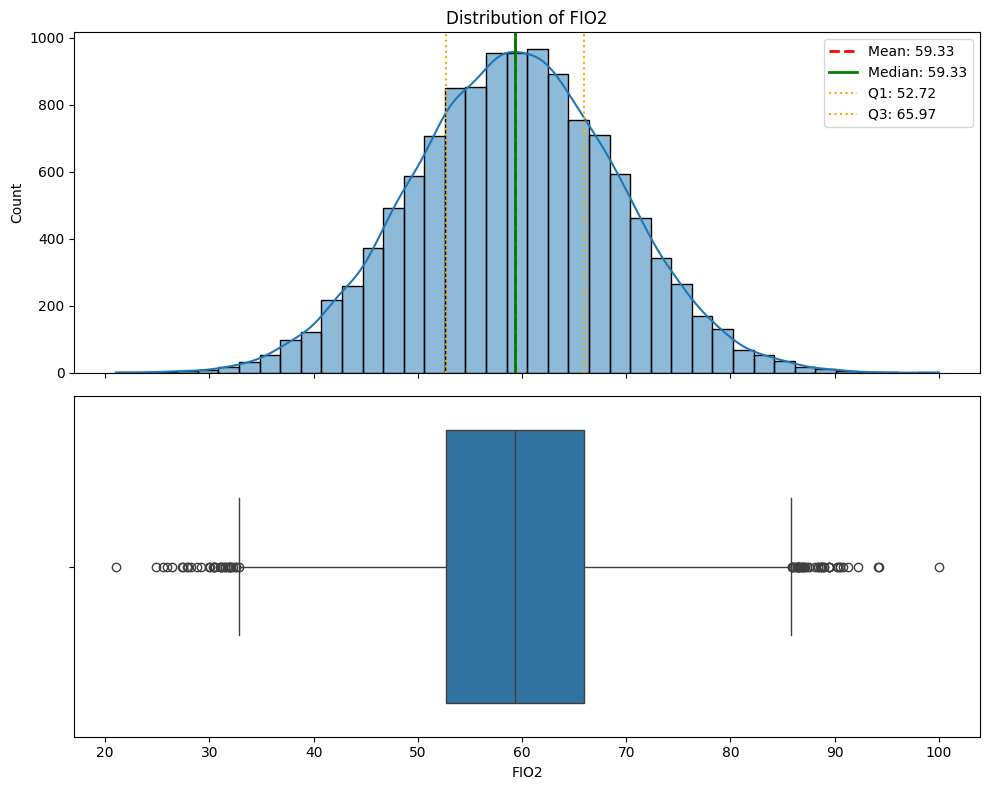


--- FIO2 ---
Probably normal
------------------------------------------------------------


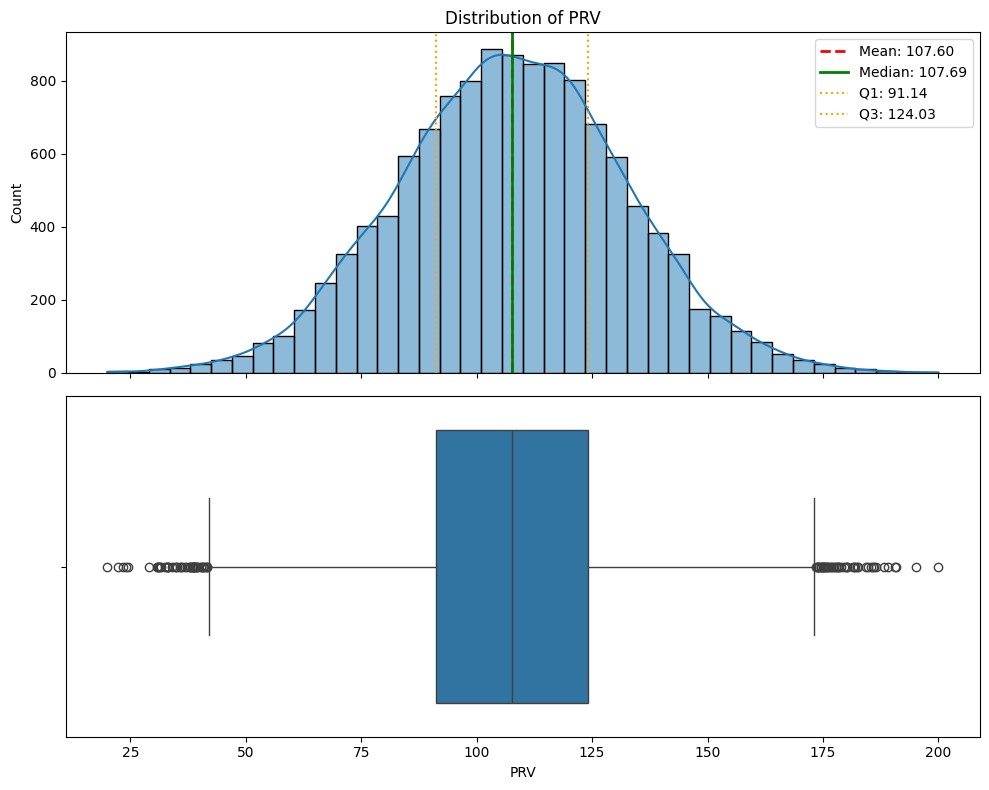


--- PRV ---
Probably normal
------------------------------------------------------------


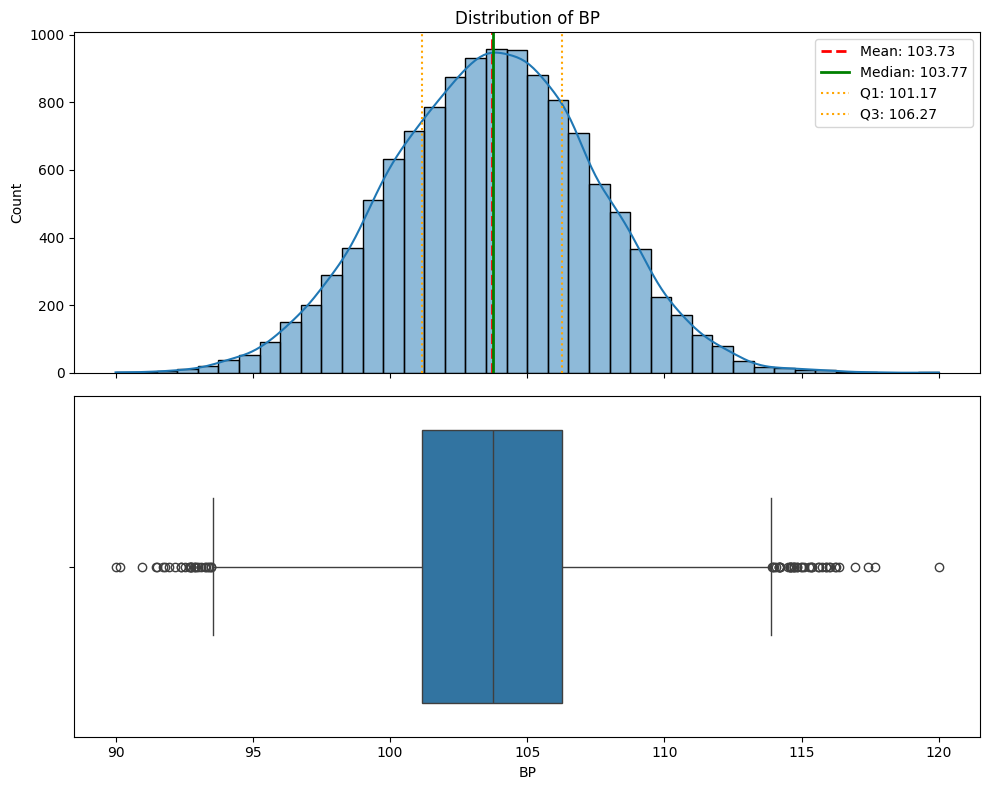


--- BP ---
Probably normal
------------------------------------------------------------


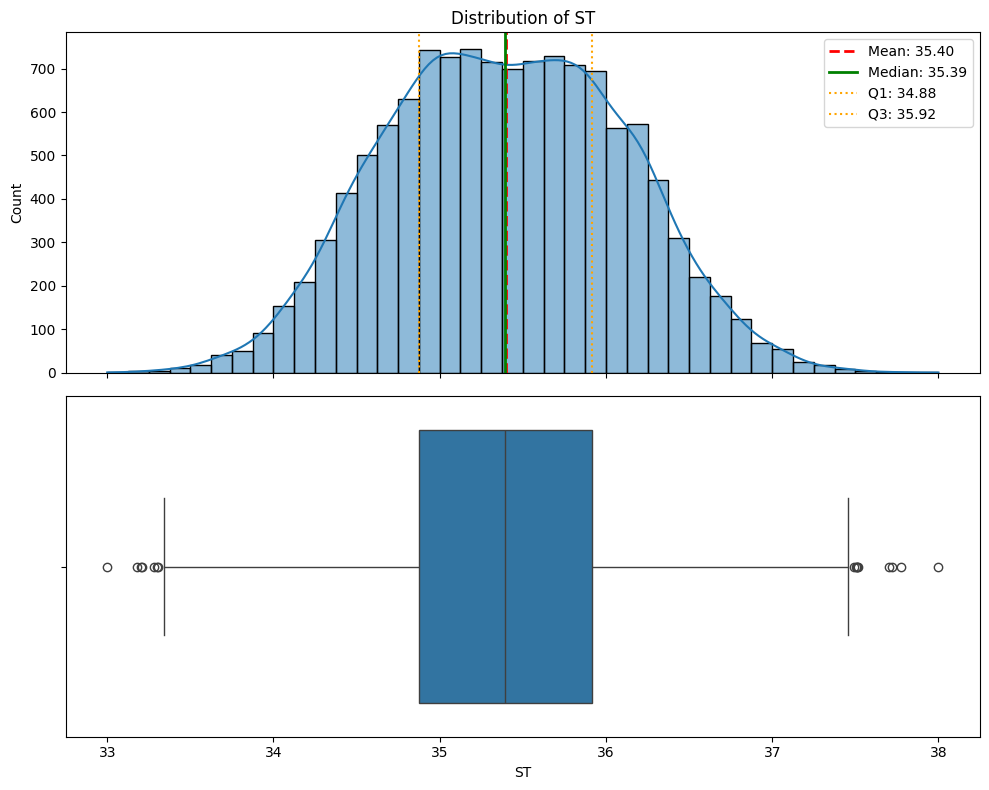


--- ST ---
Probably not normal
------------------------------------------------------------


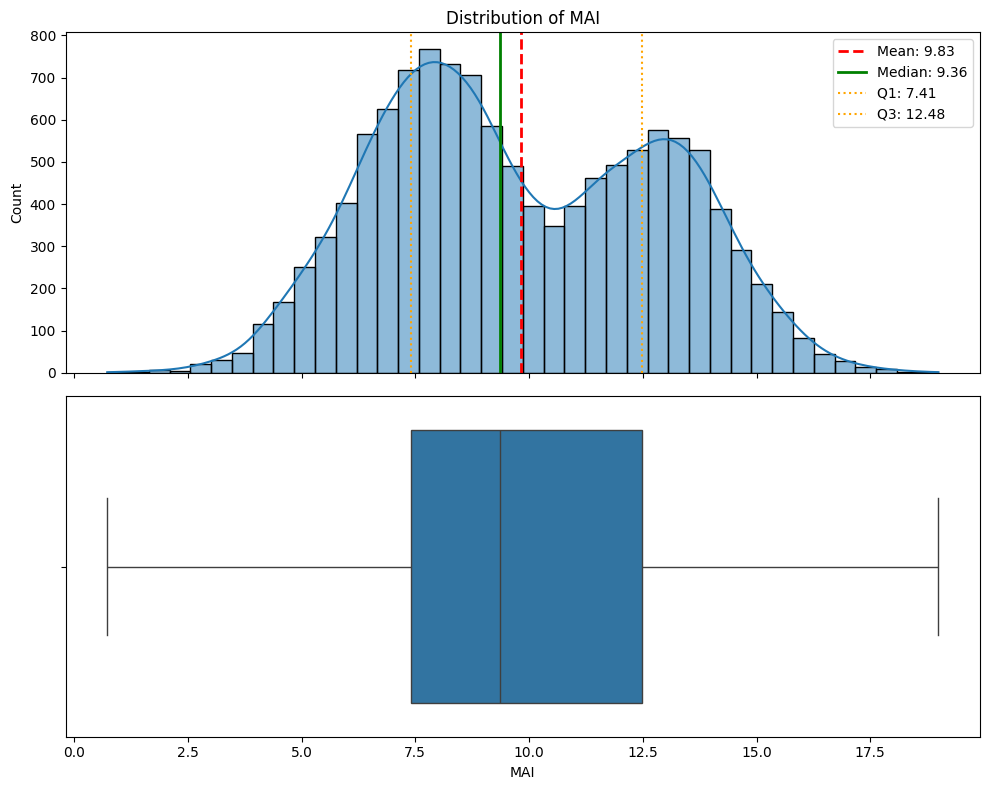


--- MAI ---
Probably not normal
------------------------------------------------------------


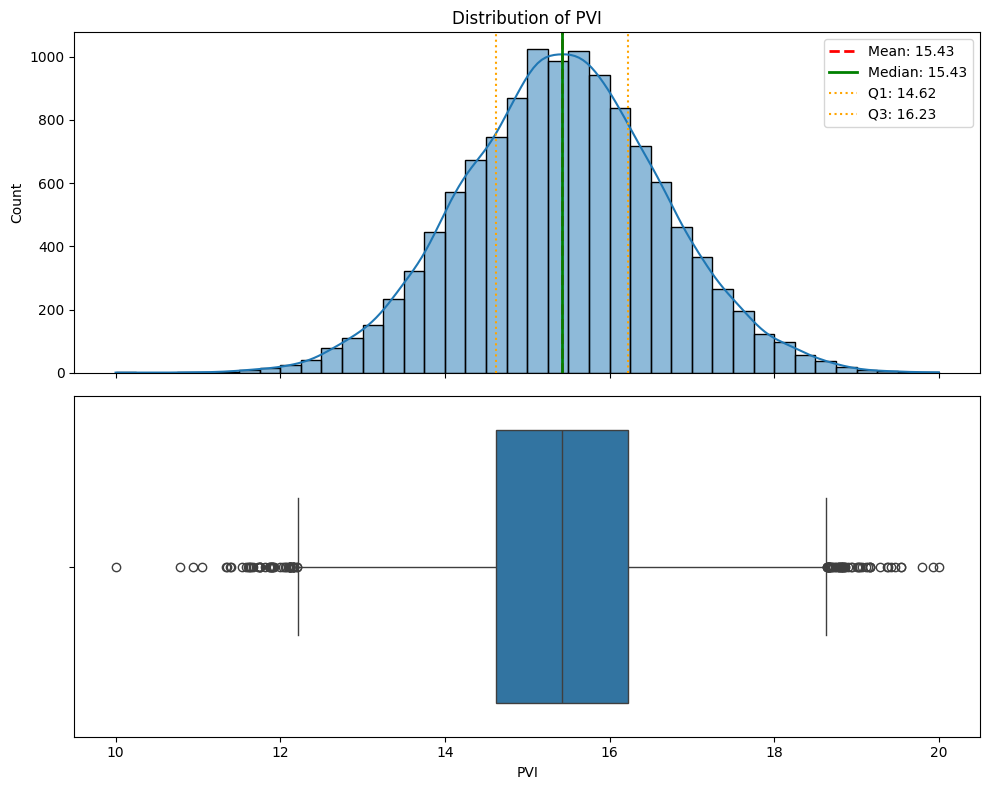


--- PVI ---
Probably normal
------------------------------------------------------------


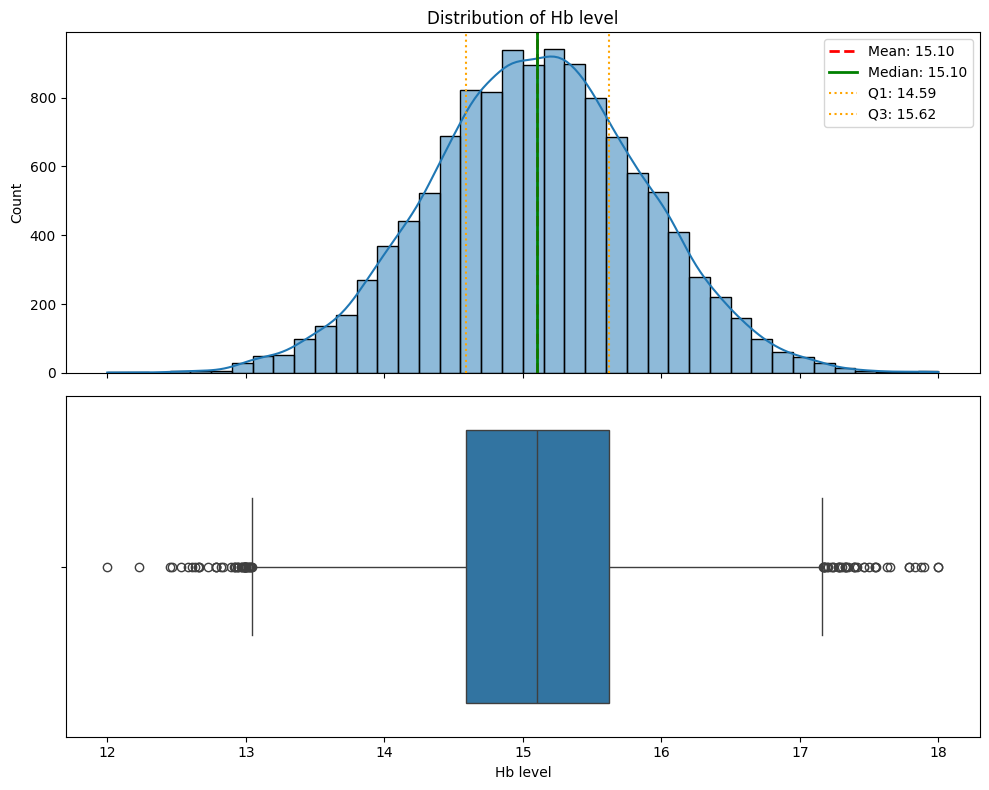


--- Hb level ---
Probably normal
------------------------------------------------------------


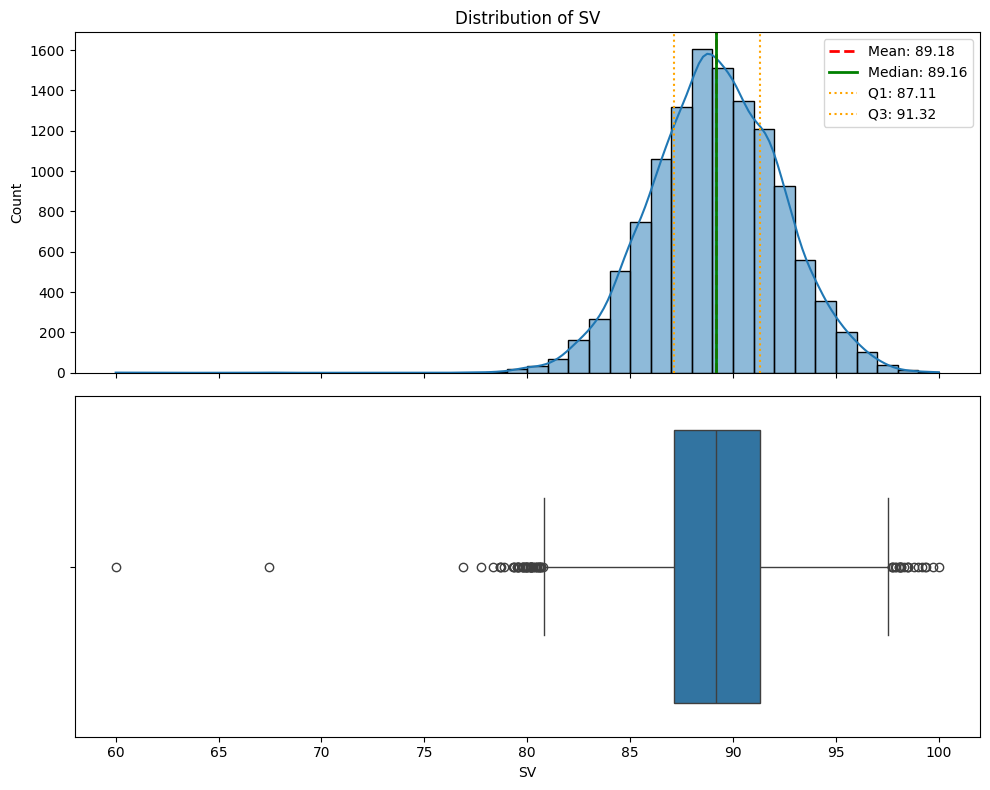


--- SV ---
Probably not normal
------------------------------------------------------------


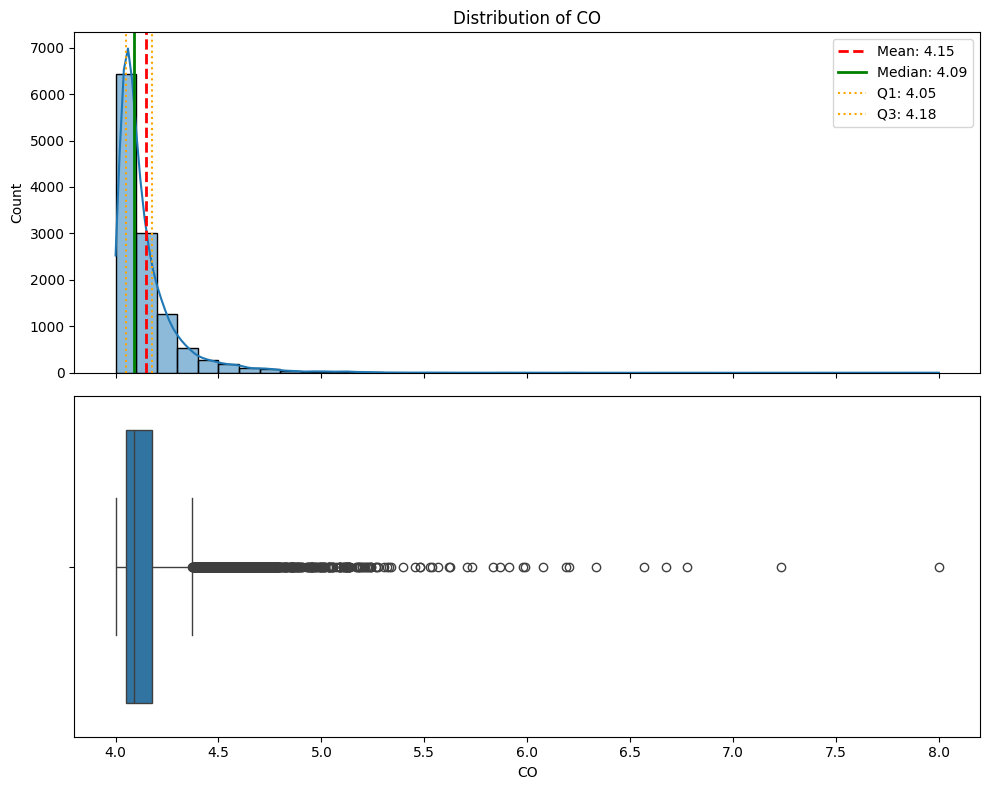


--- CO ---
Probably not normal
------------------------------------------------------------


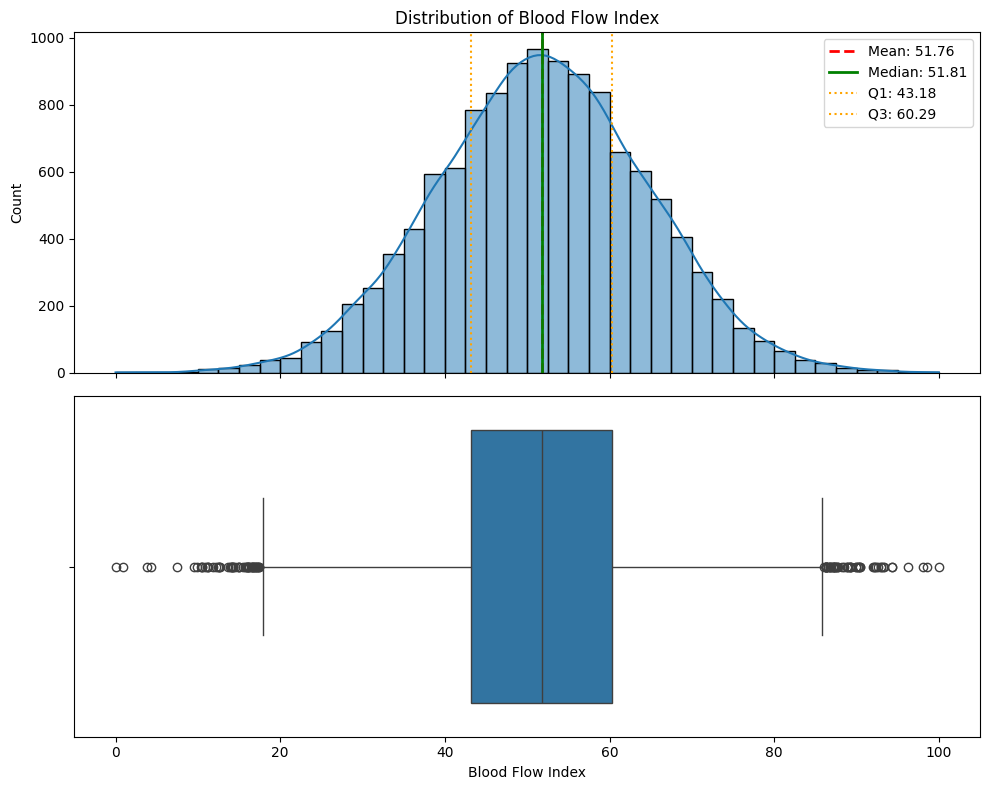


--- Blood Flow Index ---
Probably normal
------------------------------------------------------------


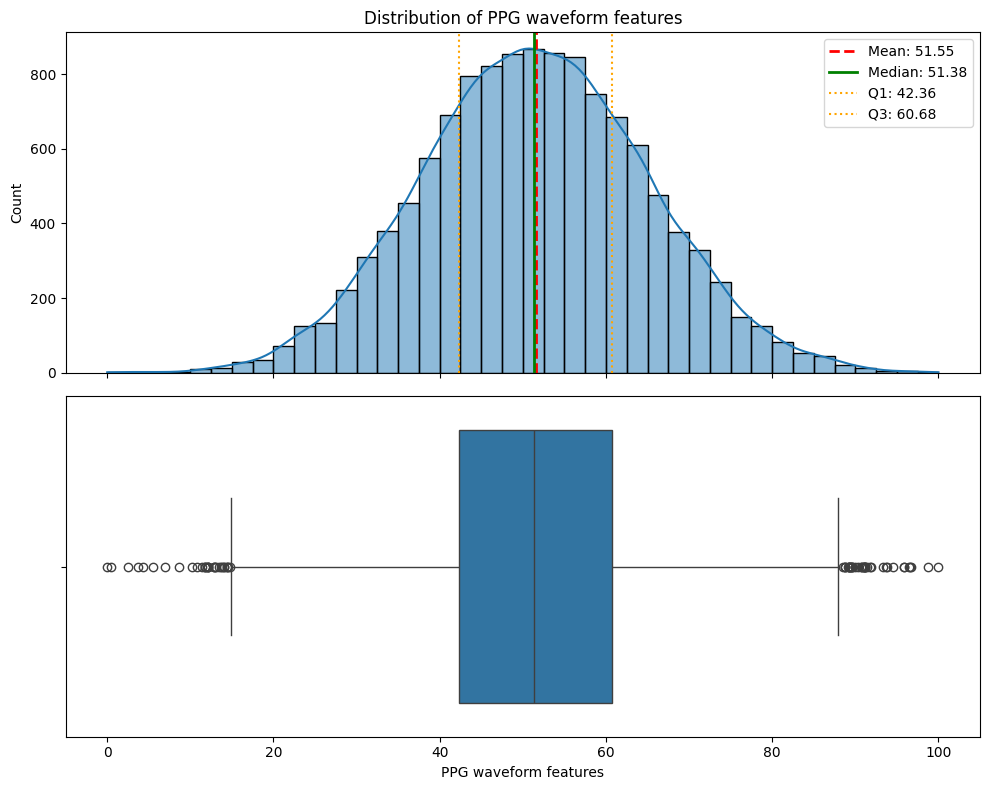


--- PPG waveform features ---
Probably normal
------------------------------------------------------------


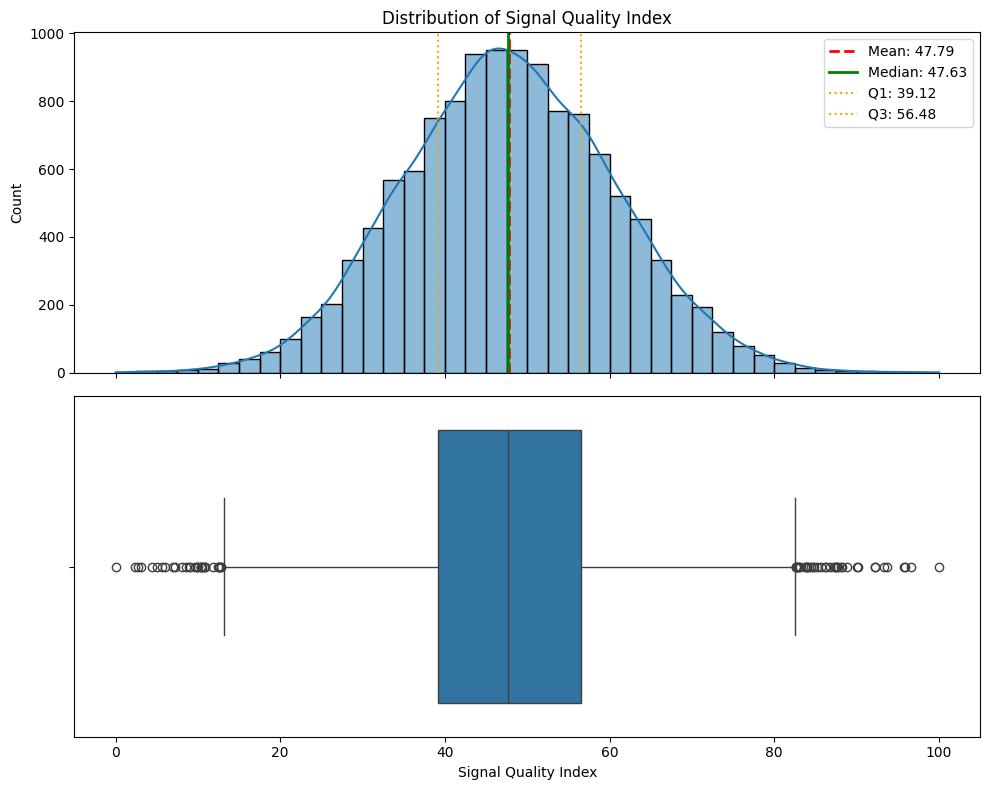


--- Signal Quality Index ---
Probably normal
------------------------------------------------------------


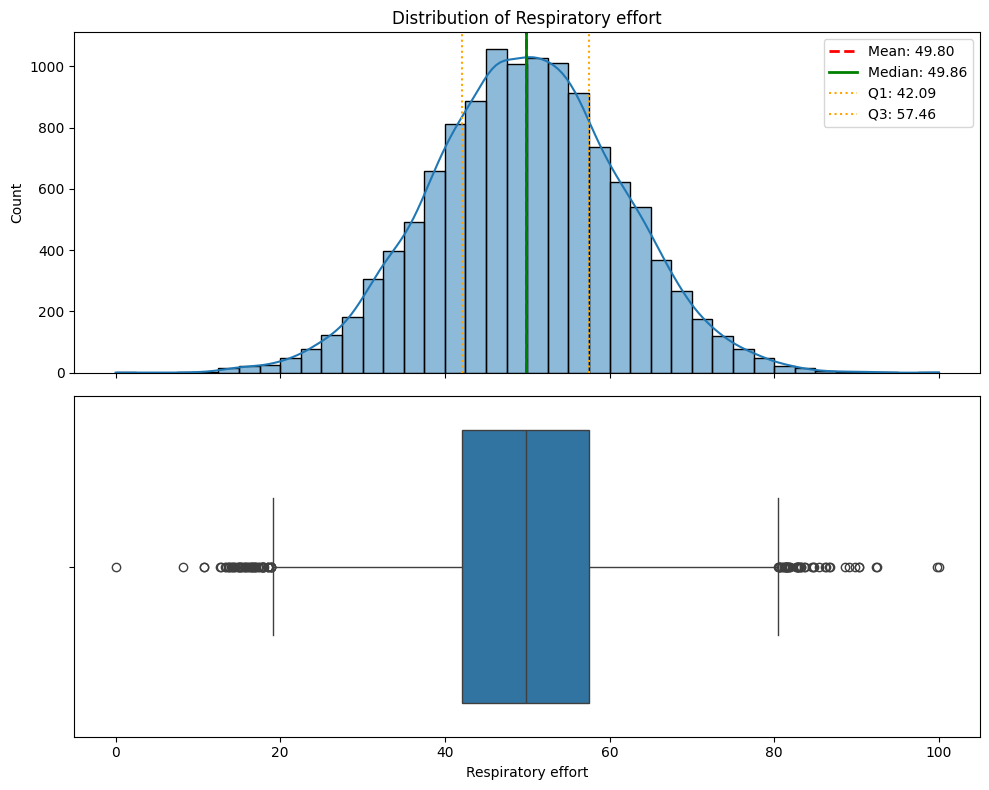


--- Respiratory effort ---
Probably normal
------------------------------------------------------------


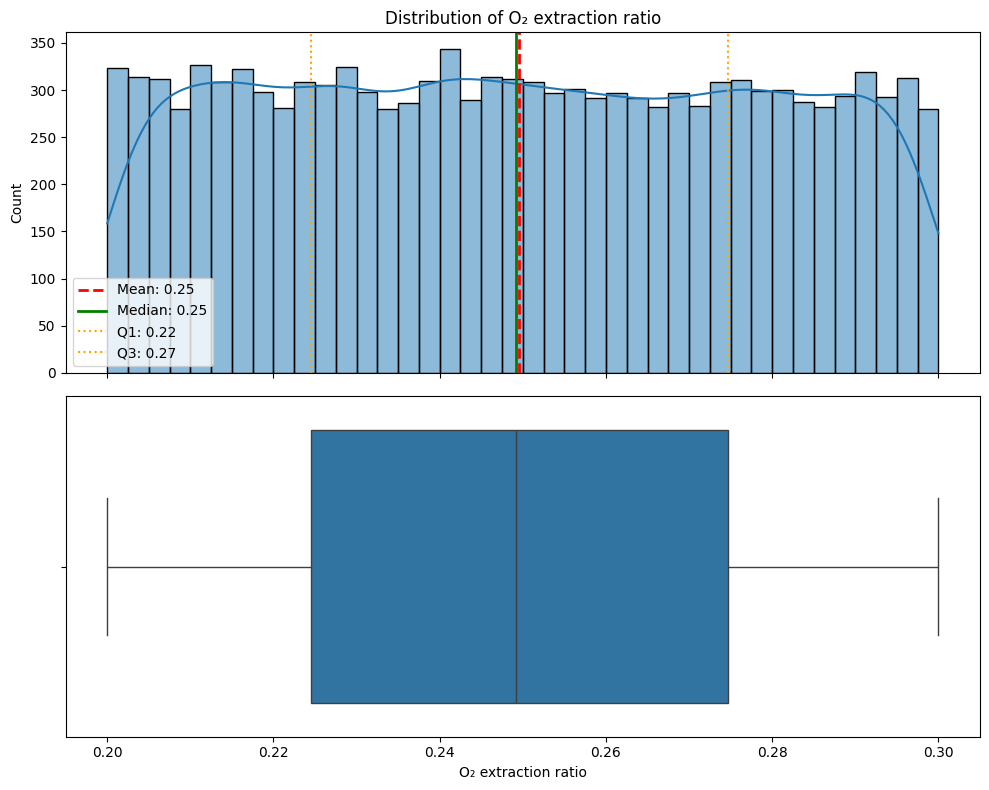


--- O₂ extraction ratio ---
Probably not normal
------------------------------------------------------------


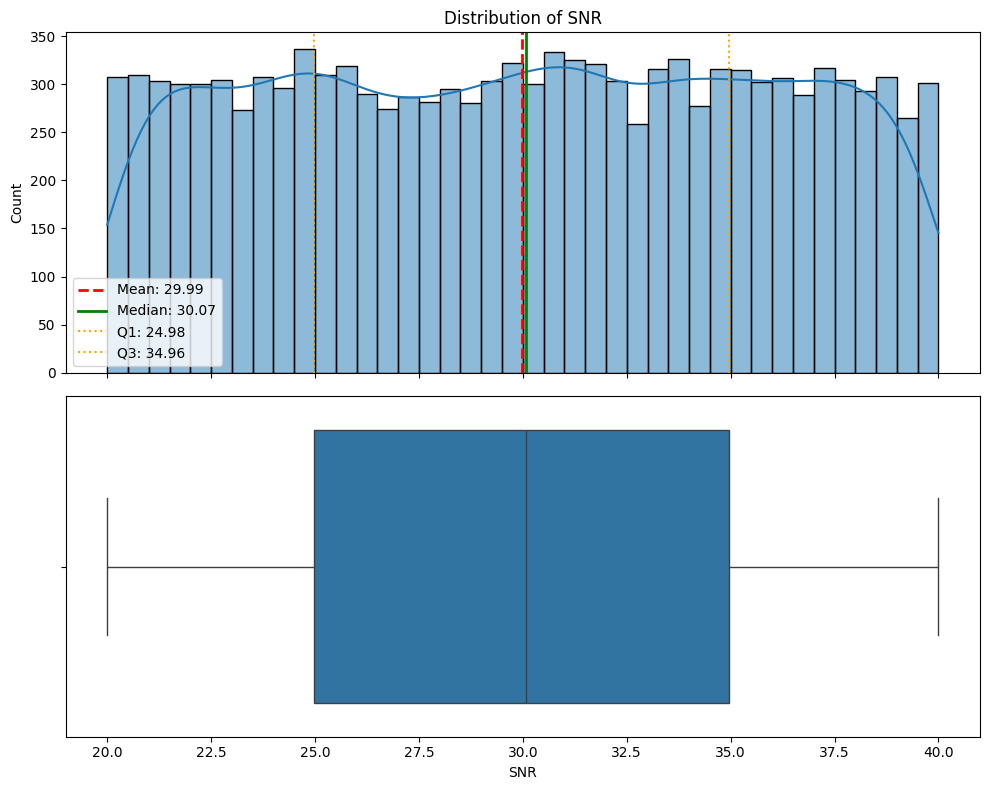


--- SNR ---
Probably not normal
------------------------------------------------------------


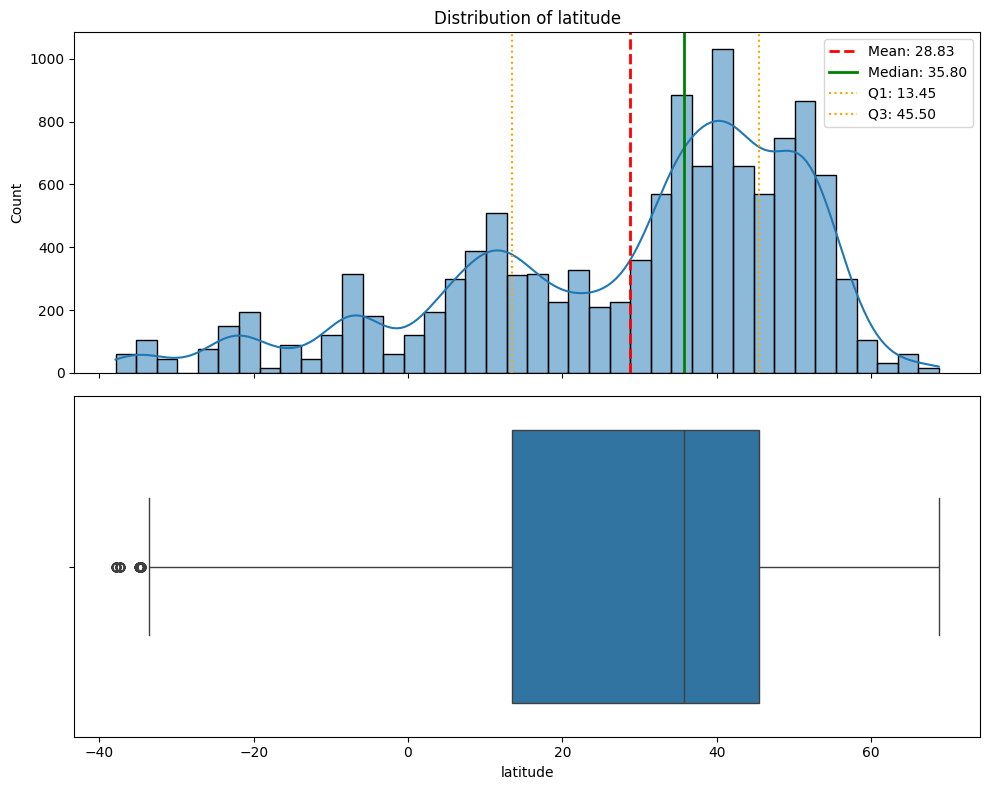


--- latitude ---
Probably not normal
------------------------------------------------------------


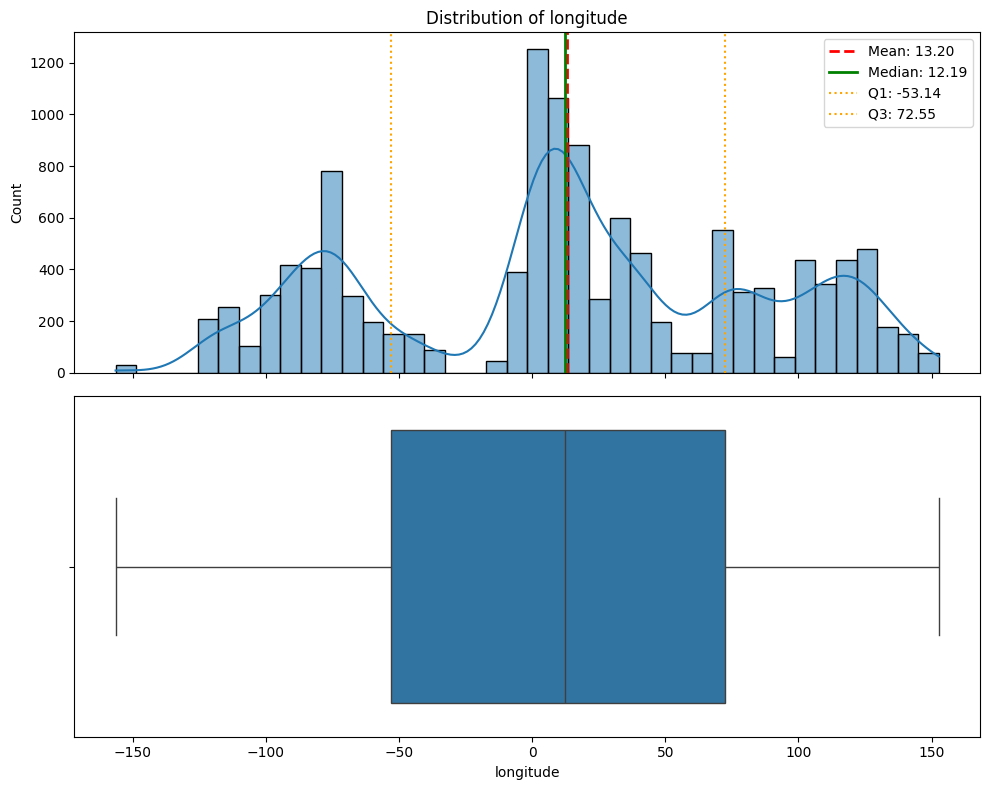


--- longitude ---
Probably not normal
------------------------------------------------------------


In [13]:
numeric_cols = [
    'SPO2',
    'HR',
    'PI',
    'RR',
    'ETCO2',
    'FIO2',
    'PRV',
    'BP',
    'ST',
    'MAI',
    'PVI',
    'Hb level',
    'SV',
    'CO',
    'Blood Flow Index',
    'PPG waveform features',
    'Signal Quality Index',
    'Respiratory effort',
    'O₂ extraction ratio',
    'SNR',
    'latitude',
    'longitude'
]
    

for col in numeric_cols:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    sns.histplot(df[col], bins=40, kde=True, ax=ax1)
    
    # Calculate statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    ax1.axvline(q1, color='orange', linestyle=':', linewidth=1.5, label=f'Q1: {q1:.2f}')
    ax1.axvline(q3, color='orange', linestyle=':', linewidth=1.5, label=f'Q3: {q3:.2f}')
    ax1.set_title(f'Distribution of {col}')
    ax1.legend()
    
    sns.boxplot(x=df[col], ax=ax2)
    ax2.set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- {col} ---")
    
    # Normality test
    stat, p = normaltest(df[col].dropna())
    if p > 0.05:
        print("Probably normal")
    else:
        print("Probably not normal")
    print("-" * 60)

# Now we divide data into train and test

In [14]:
(df['oximetry'] == 0).sum()

np.int64(4908)

In [15]:
(df['oximetry'] == 1).sum()

np.int64(7164)

The target in dataset is moderetaly imbalanced 40 : 60

In [16]:
TARGET = 'oximetry'

DROP_COLS = [
    'location'
]

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training size: {X_train.shape}, Test size: {X_test.shape}")

Training size: (8450, 24), Test size: (3622, 24)


Before splitting the dataset, we checked the distribution of the target variable (oximetry). The dataset contains 4908 samples of class 0 (40%) and 7164 samples of class 1 (60%). Since the dataset is moderately imbalanced, we used train_test_split with the stratify parameter to ensure that both training and test sets maintain the same class proportions.

# Outliers

### Defining based on eda what outlier rule is going to be used on which attribute

With EDA analysis we have discovered diff distibution per attributes. Therefore we choose a method for preprocessing where we apply SD detection for normal distribution and IQR for the rest. These methods are going to be used in the pipeline.

In [17]:
WINSOR_METHODS = {
    'SPO2': 'IQR',
    'HR': 'SD',
    'PI': 'IQR',
    'RR': 'SD',
    'FIO2': 'SD',
    'ETCO2': 'IQR',
    'MAI': 'IQR',
    'PRV': 'SD',
    'BP': 'SD',
    'ST': 'SD',
    'CO': 'IQR',
    'PVI': 'SD',
    'Hb level': 'SD',
    'SV': 'IQR',
    'Blood Flow Index': 'SD',
    'PPG waveform features': 'SD',
    'Signal Quality Index': 'SD',
    'Respiratory effort': 'SD',
    'O₂ extraction ratio': 'IQR',
    'SNR': 'IQR',
    'latitude': 'IQR',
    'longitude': 'IQR'
}

Visualizing the winorization on train data


 ***** SPO2 (IQR method) *****
Train outliers BEFORE: lower=1, upper=0
Soft bounds: [96.316, 99.020]
Train outliers AFTER: lower=1, upper=0


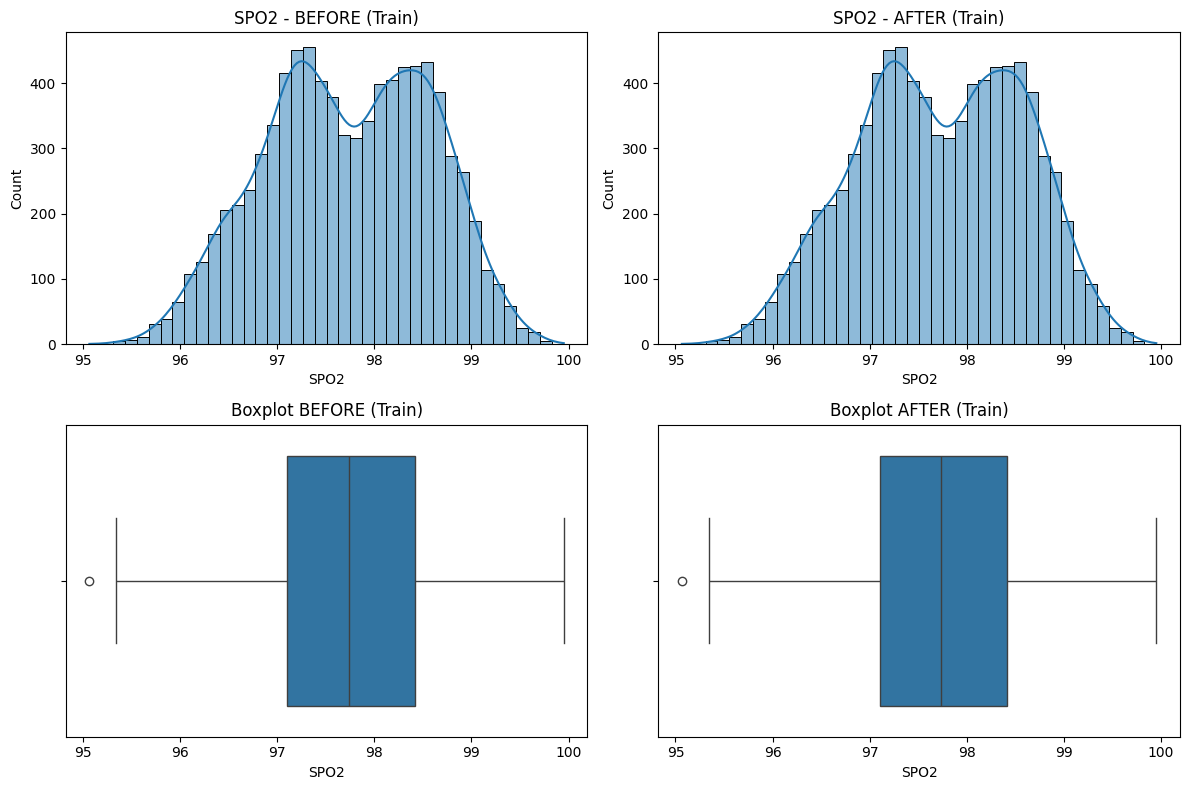

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** HR (SD method) *****
Train outliers BEFORE: lower=4, upper=13
Soft bounds: [70.248, 88.306]
Train outliers AFTER: lower=3, upper=11


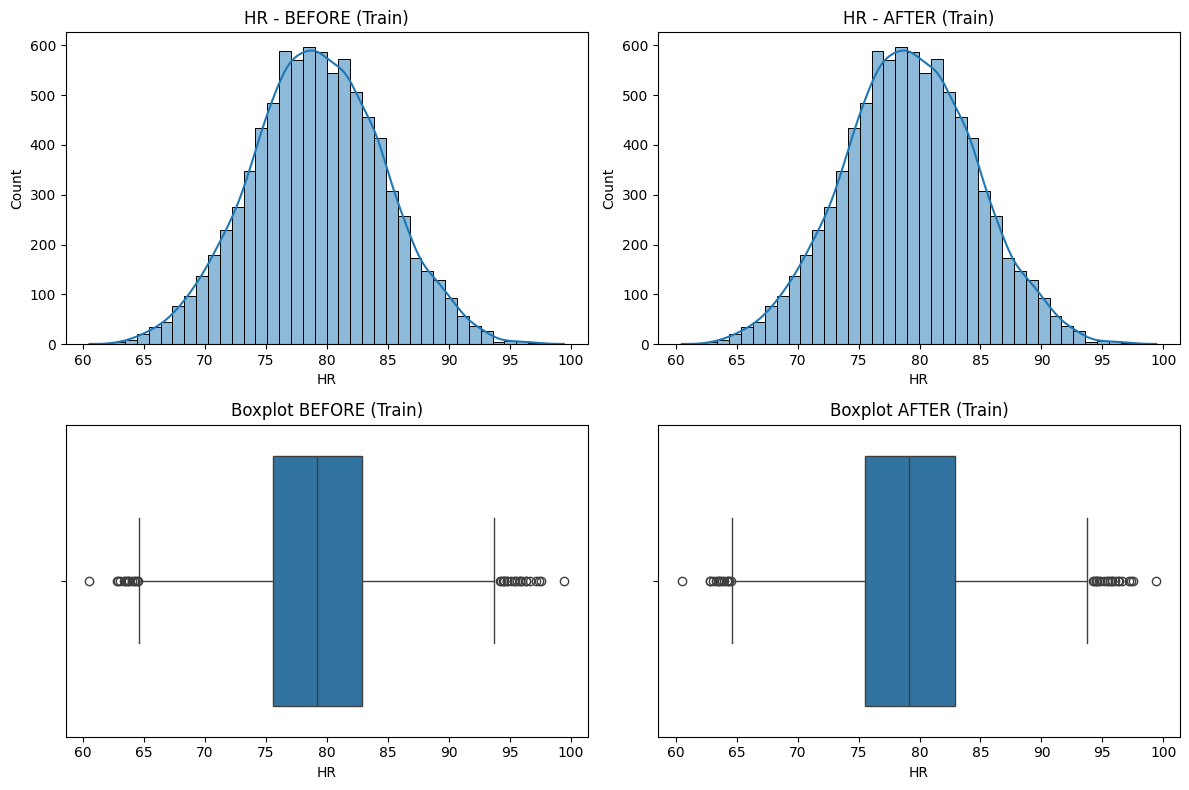

Normality BEFORE (p=0.0804) → normal
Normality AFTER  (p=0.0804) → normal
------------------------------------------------------------

 ***** PI (IQR method) *****
Train outliers BEFORE: lower=0, upper=0
Soft bounds: [4.098, 14.946]
Train outliers AFTER: lower=0, upper=0


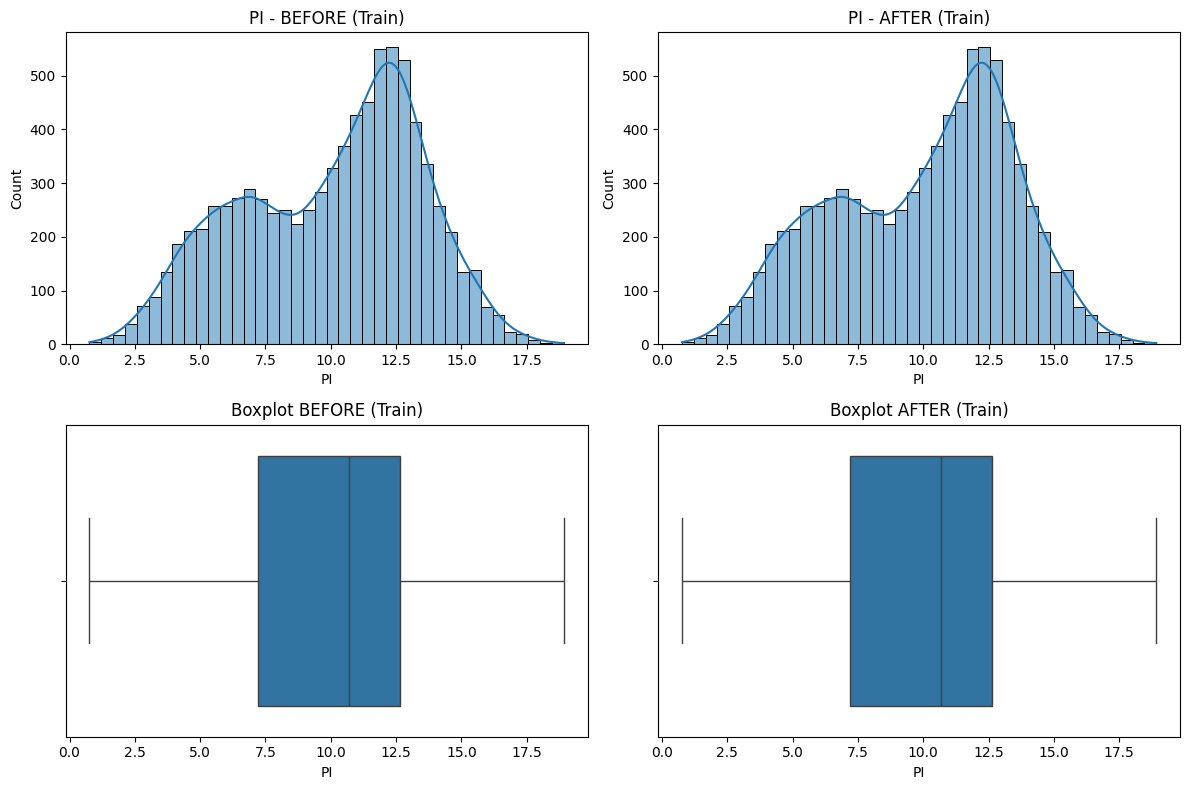

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** RR (SD method) *****
Train outliers BEFORE: lower=14, upper=6
Soft bounds: [14.038, 17.226]
Train outliers AFTER: lower=12, upper=4


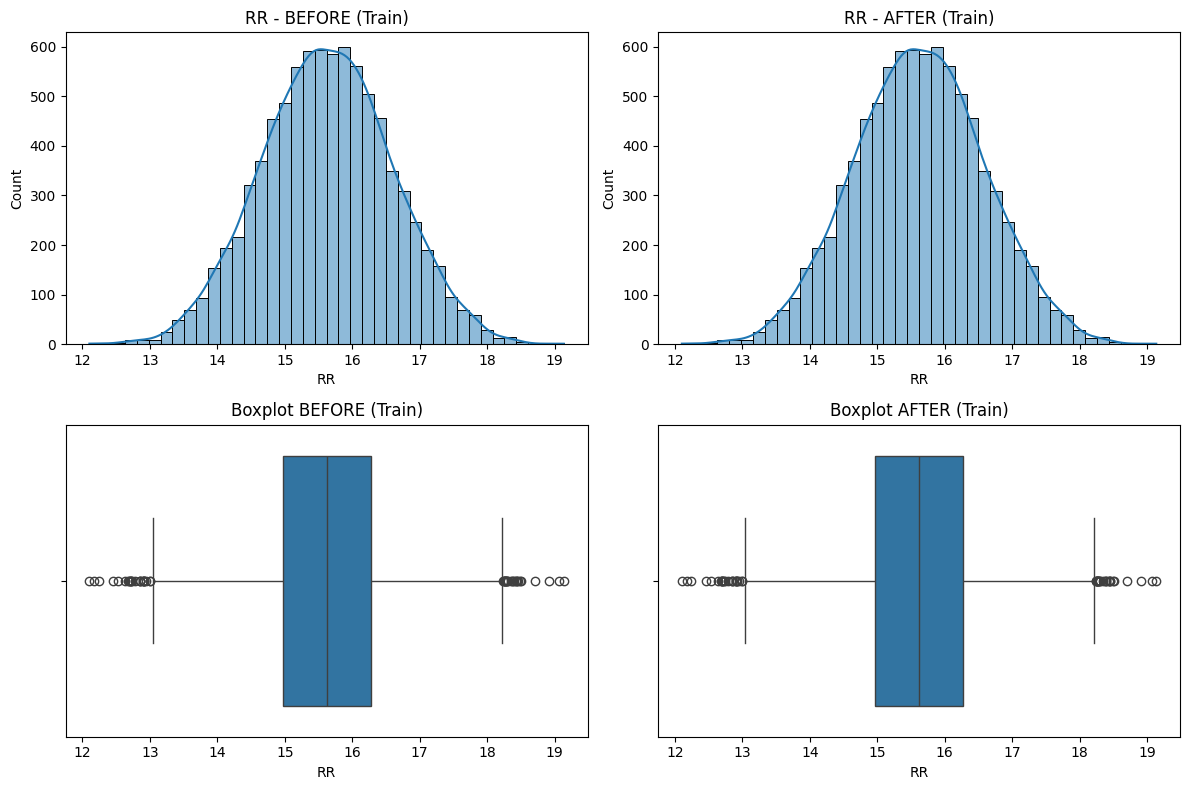

Normality BEFORE (p=0.0605) → normal
Normality AFTER  (p=0.0605) → normal
------------------------------------------------------------

 ***** FIO2 (SD method) *****
Train outliers BEFORE: lower=11, upper=14
Soft bounds: [42.966, 75.473]
Train outliers AFTER: lower=11, upper=7


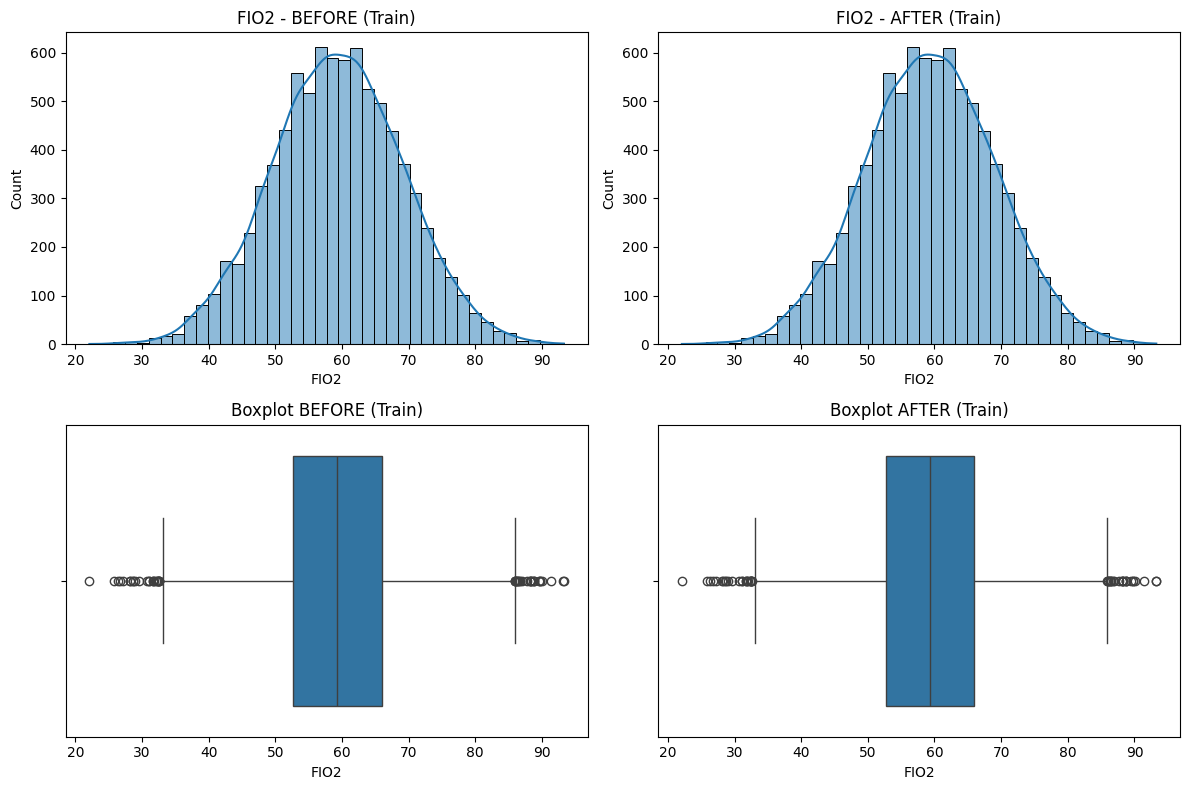

Normality BEFORE (p=0.3193) → normal
Normality AFTER  (p=0.3193) → normal
------------------------------------------------------------

 ***** ETCO2 (IQR method) *****
Train outliers BEFORE: lower=76, upper=70
Soft bounds: [38.024, 41.961]
Train outliers AFTER: lower=70, upper=58


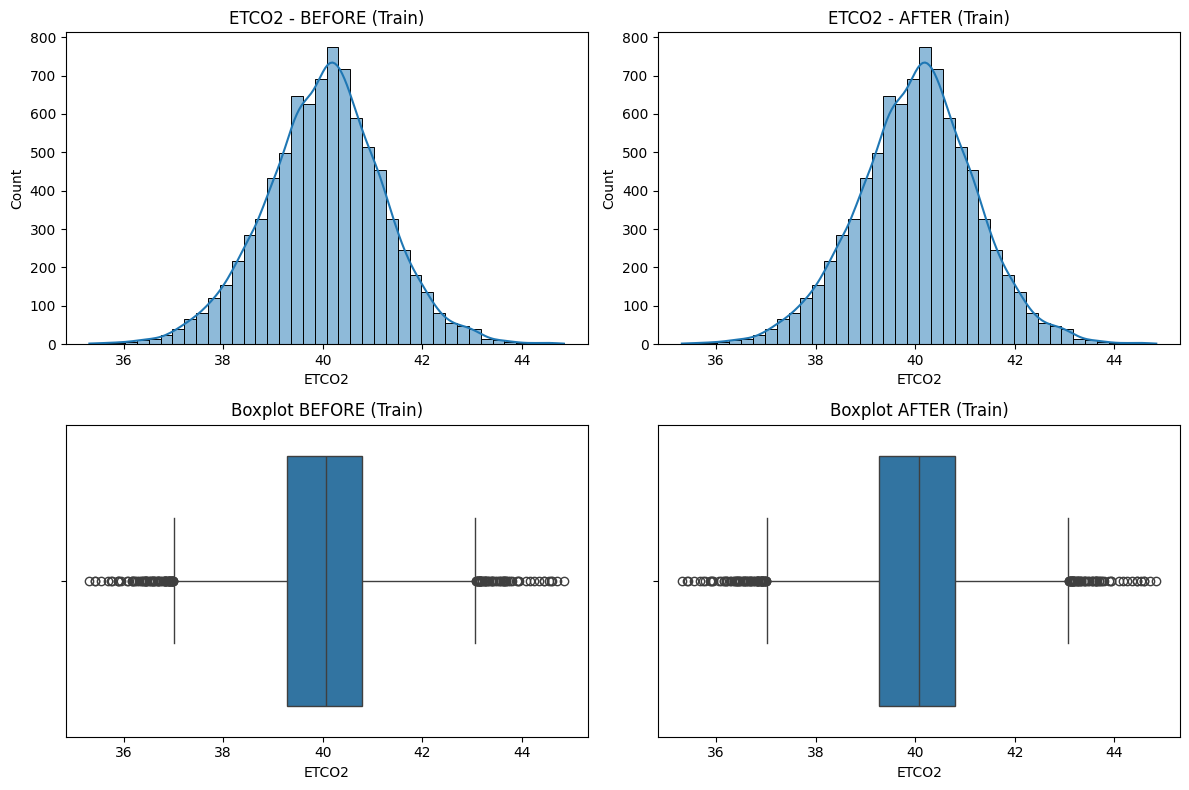

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** MAI (IQR method) *****
Train outliers BEFORE: lower=0, upper=0
Soft bounds: [5.246, 14.767]
Train outliers AFTER: lower=0, upper=0


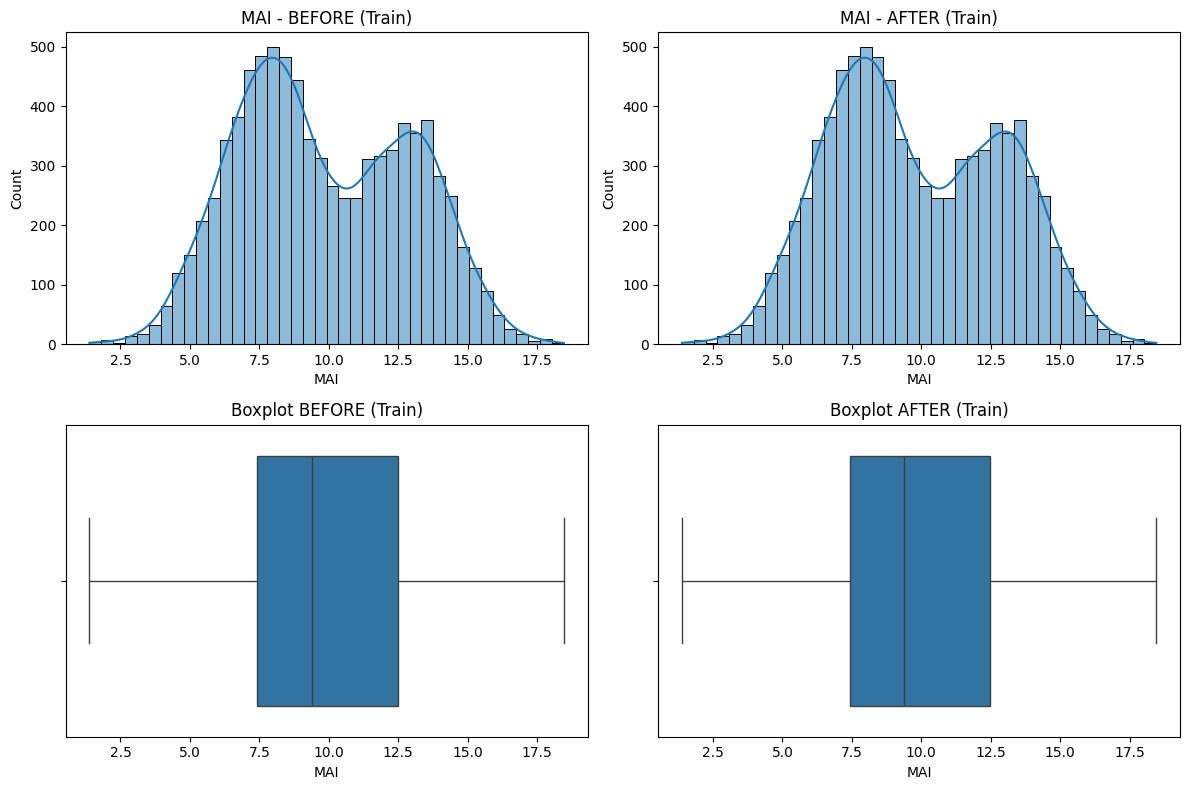

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** PRV (SD method) *****
Train outliers BEFORE: lower=9, upper=11
Soft bounds: [67.387, 147.923]
Train outliers AFTER: lower=7, upper=9


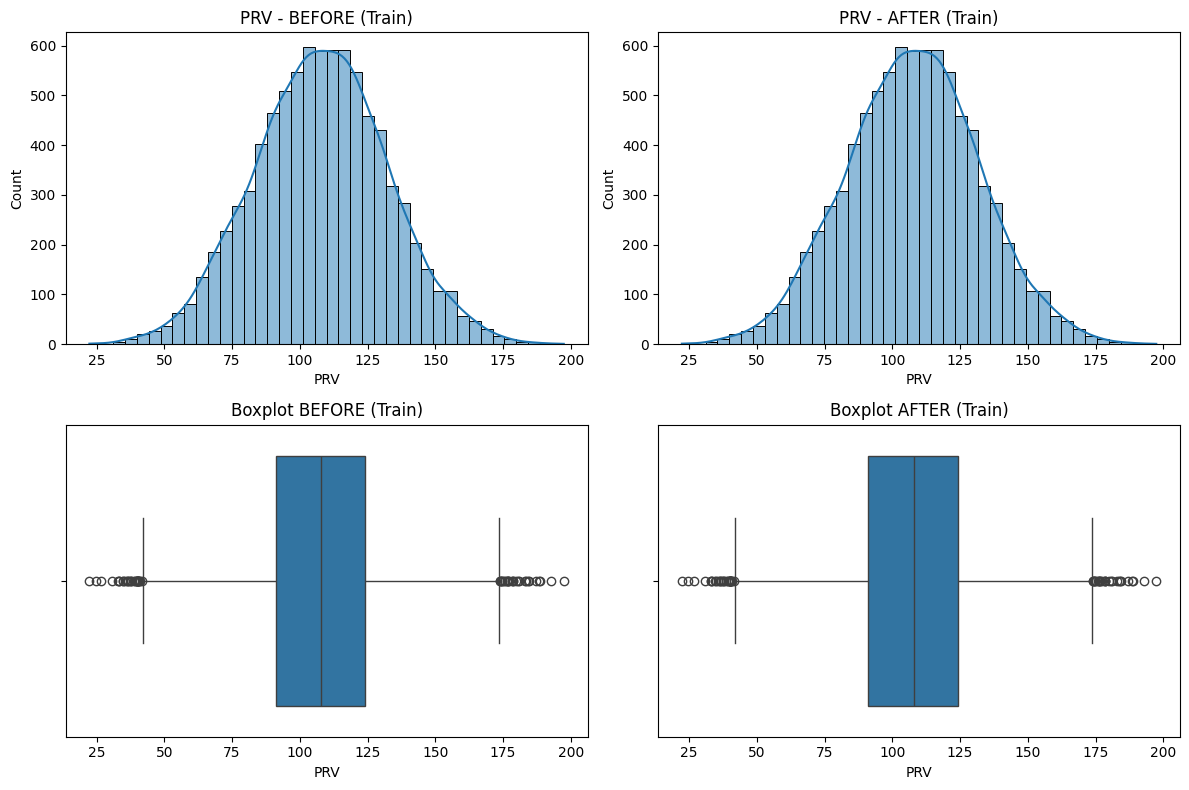

Normality BEFORE (p=0.6525) → normal
Normality AFTER  (p=0.6525) → normal
------------------------------------------------------------

 ***** BP (SD method) *****
Train outliers BEFORE: lower=5, upper=18
Soft bounds: [97.605, 109.733]
Train outliers AFTER: lower=5, upper=17


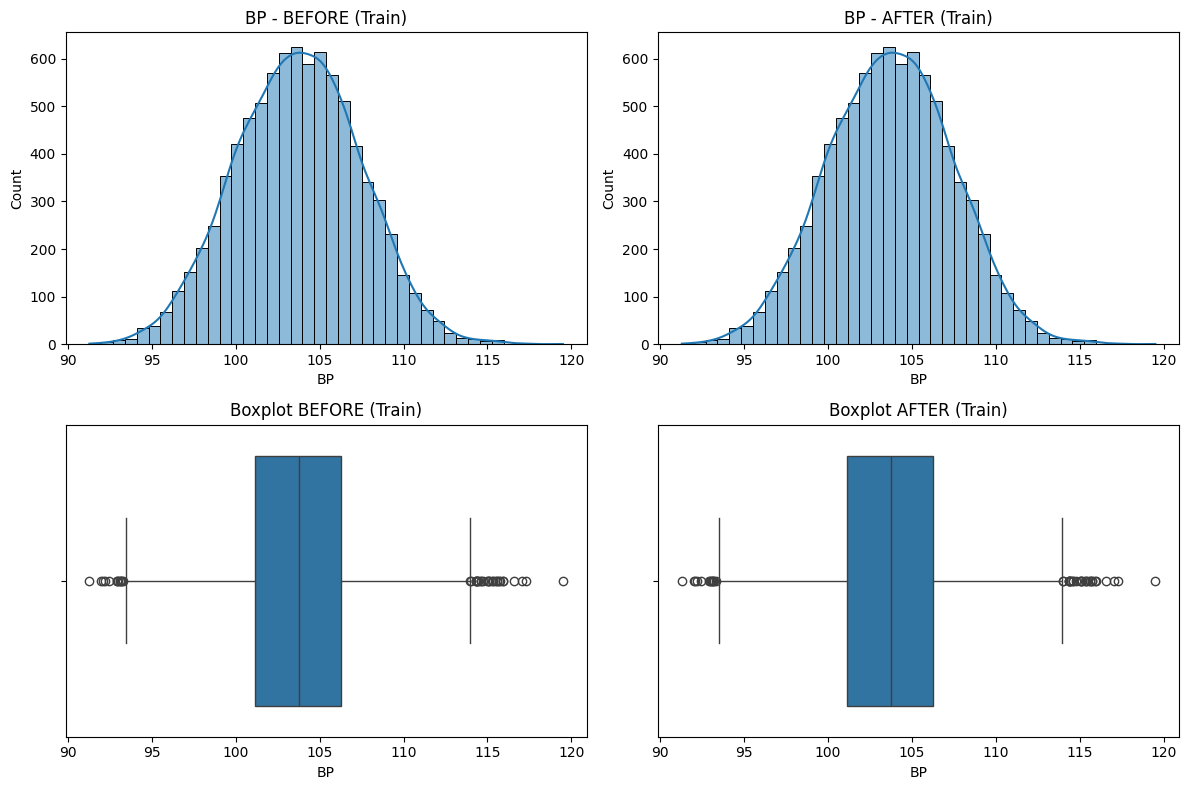

Normality BEFORE (p=0.0729) → normal
Normality AFTER  (p=0.0729) → normal
------------------------------------------------------------

 ***** ST (SD method) *****
Train outliers BEFORE: lower=3, upper=2
Soft bounds: [34.256, 36.542]
Train outliers AFTER: lower=2, upper=2


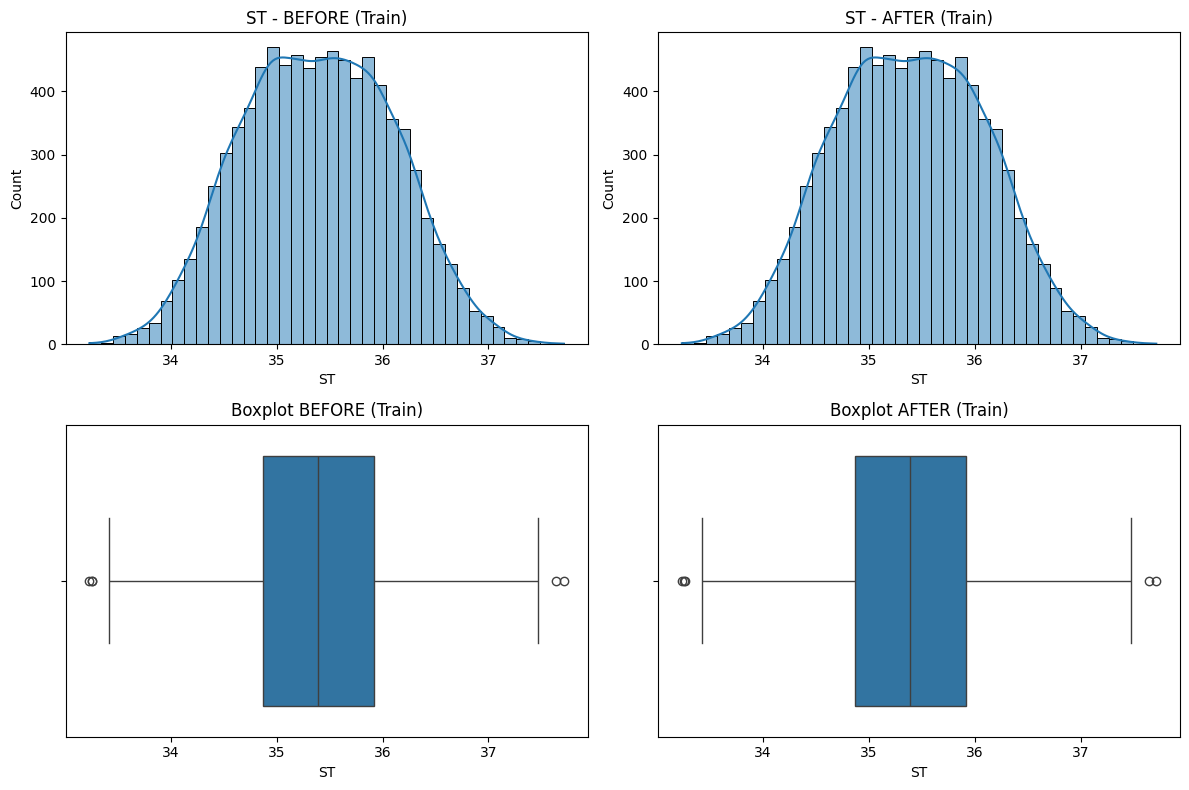

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** CO (IQR method) *****
Train outliers BEFORE: lower=0, upper=631
Soft bounds: [4.022, 4.467]
Train outliers AFTER: lower=0, upper=631


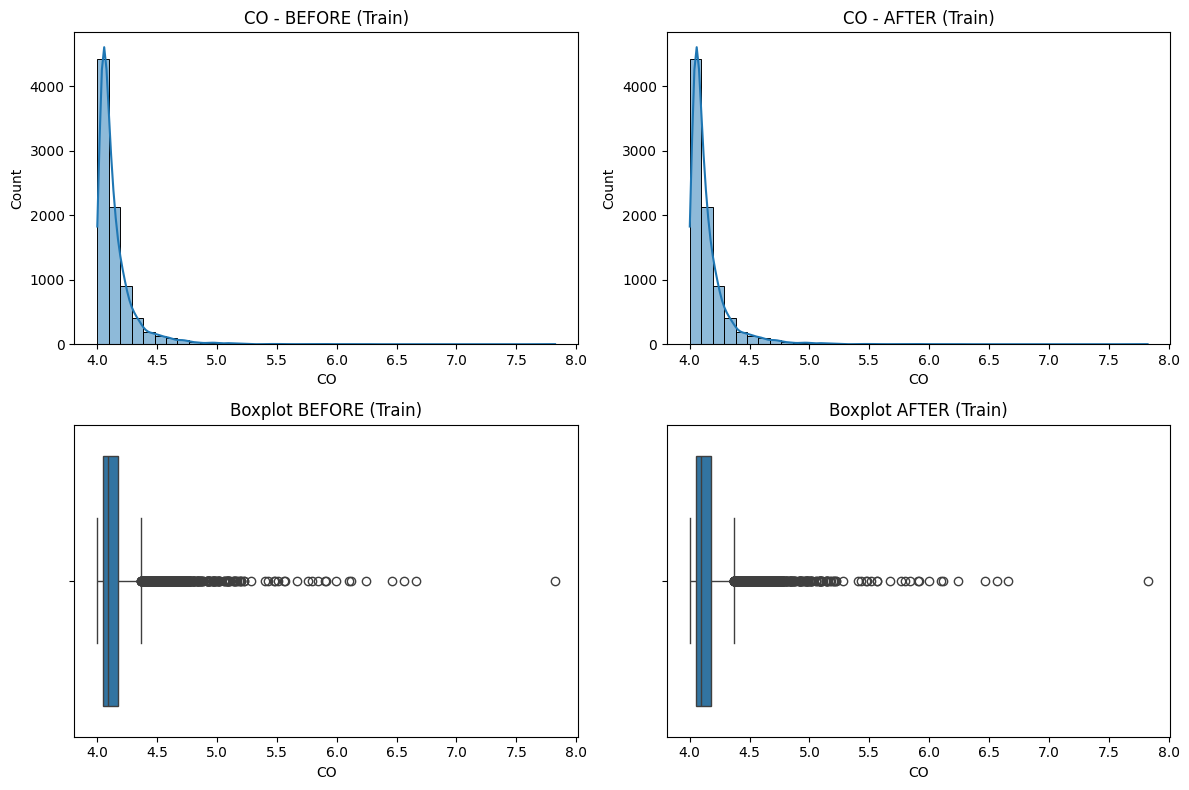

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** PVI (SD method) *****
Train outliers BEFORE: lower=13, upper=11
Soft bounds: [13.453, 17.464]
Train outliers AFTER: lower=10, upper=9


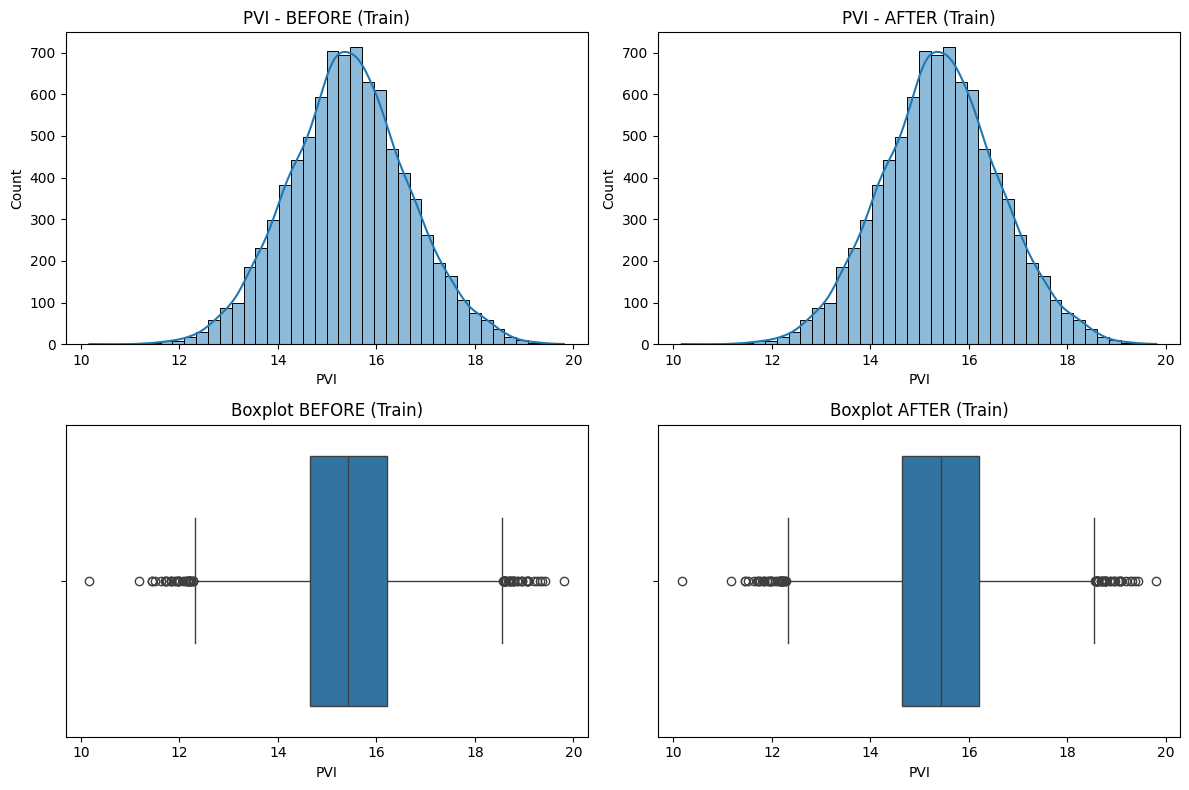

Normality BEFORE (p=0.5732) → normal
Normality AFTER  (p=0.5732) → normal
------------------------------------------------------------

 ***** Hb level (SD method) *****
Train outliers BEFORE: lower=11, upper=10
Soft bounds: [13.837, 16.357]
Train outliers AFTER: lower=8, upper=9


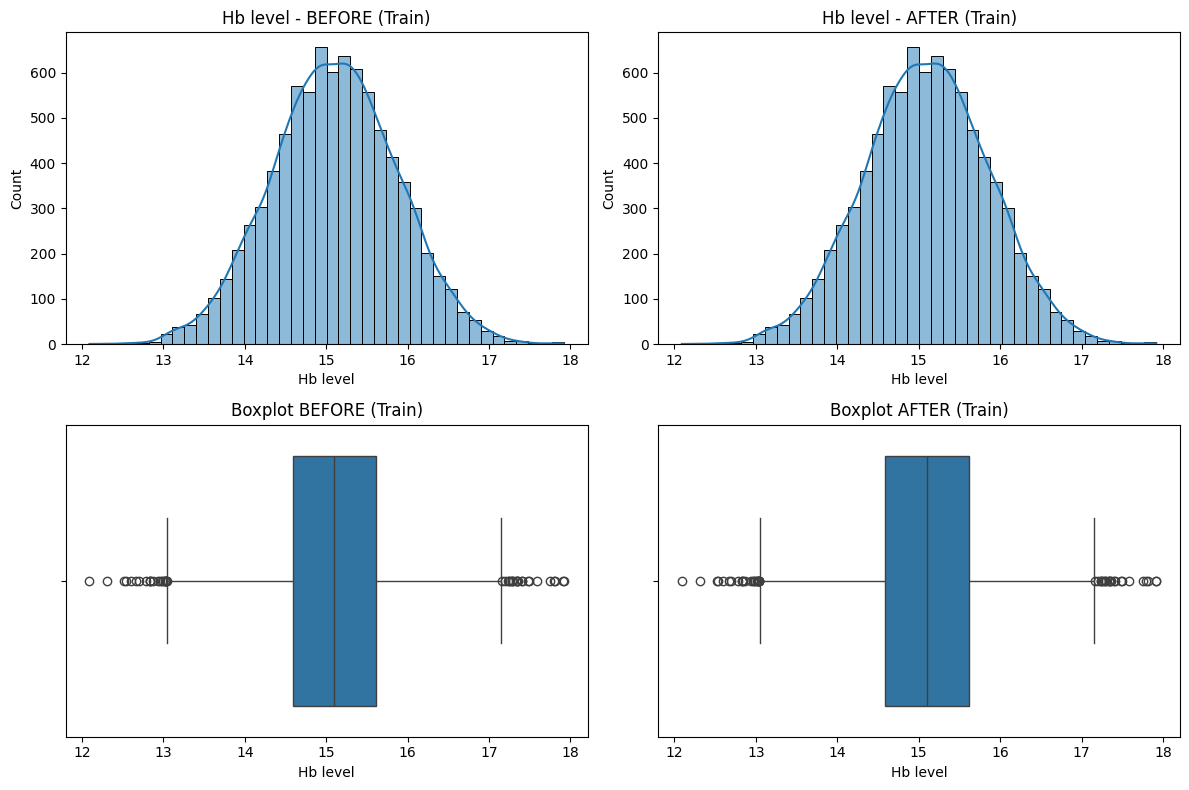

Normality BEFORE (p=0.5034) → normal
Normality AFTER  (p=0.5034) → normal
------------------------------------------------------------

 ***** SV (IQR method) *****
Train outliers BEFORE: lower=33, upper=16
Soft bounds: [84.077, 94.219]
Train outliers AFTER: lower=32, upper=14


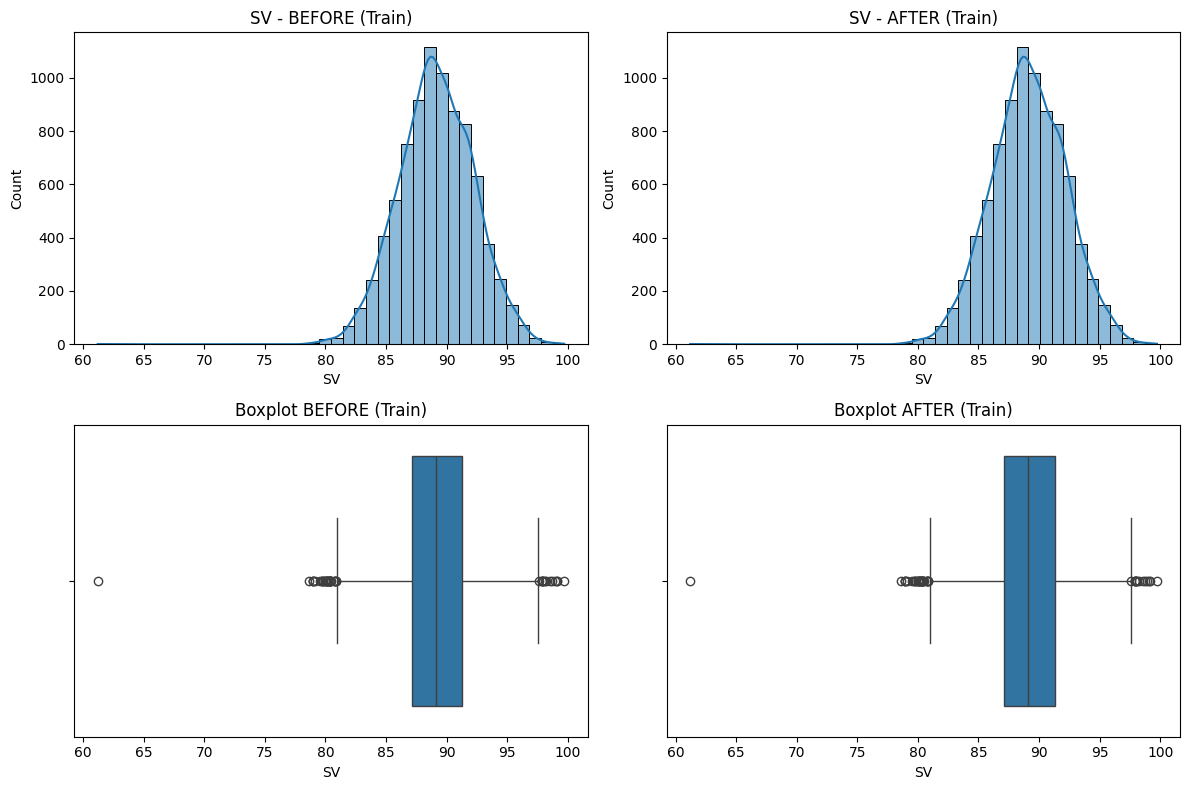

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** Blood Flow Index (SD method) *****
Train outliers BEFORE: lower=16, upper=12
Soft bounds: [30.421, 72.749]
Train outliers AFTER: lower=12, upper=12


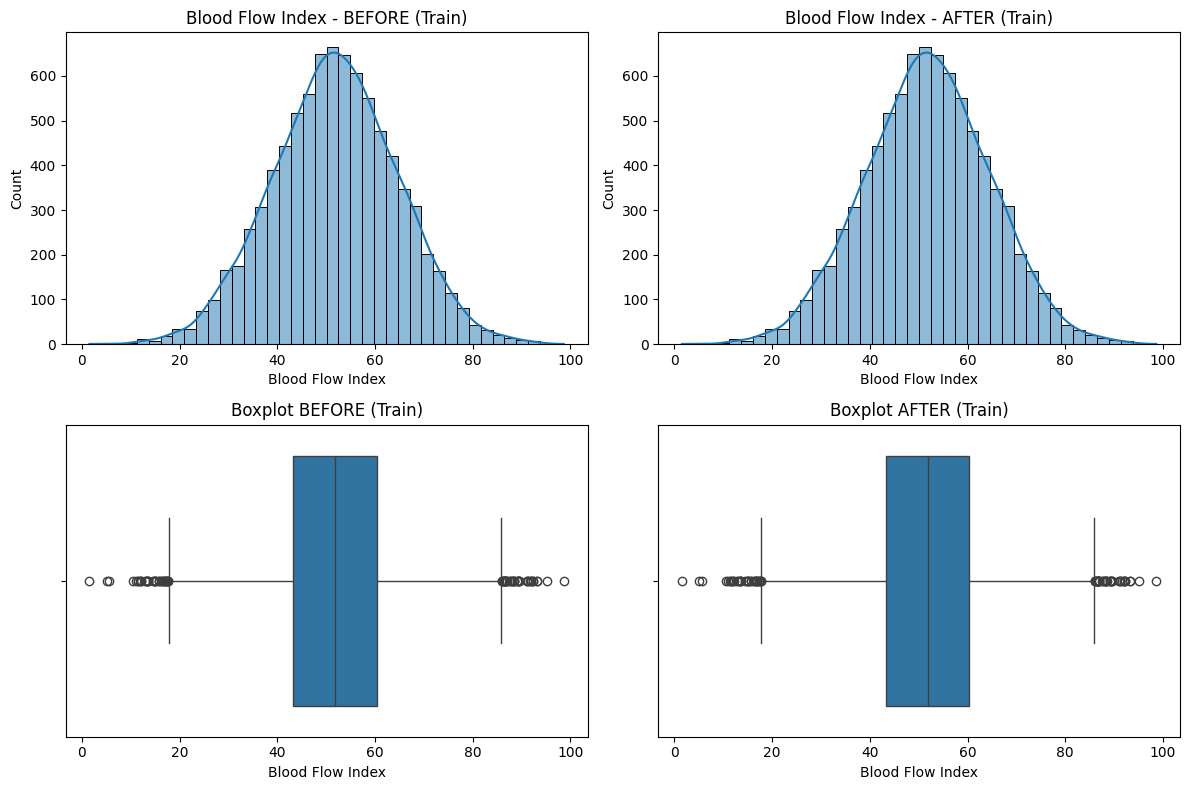

Normality BEFORE (p=0.7075) → normal
Normality AFTER  (p=0.7075) → normal
------------------------------------------------------------

 ***** PPG waveform features (SD method) *****
Train outliers BEFORE: lower=6, upper=11
Soft bounds: [29.449, 73.755]
Train outliers AFTER: lower=5, upper=11


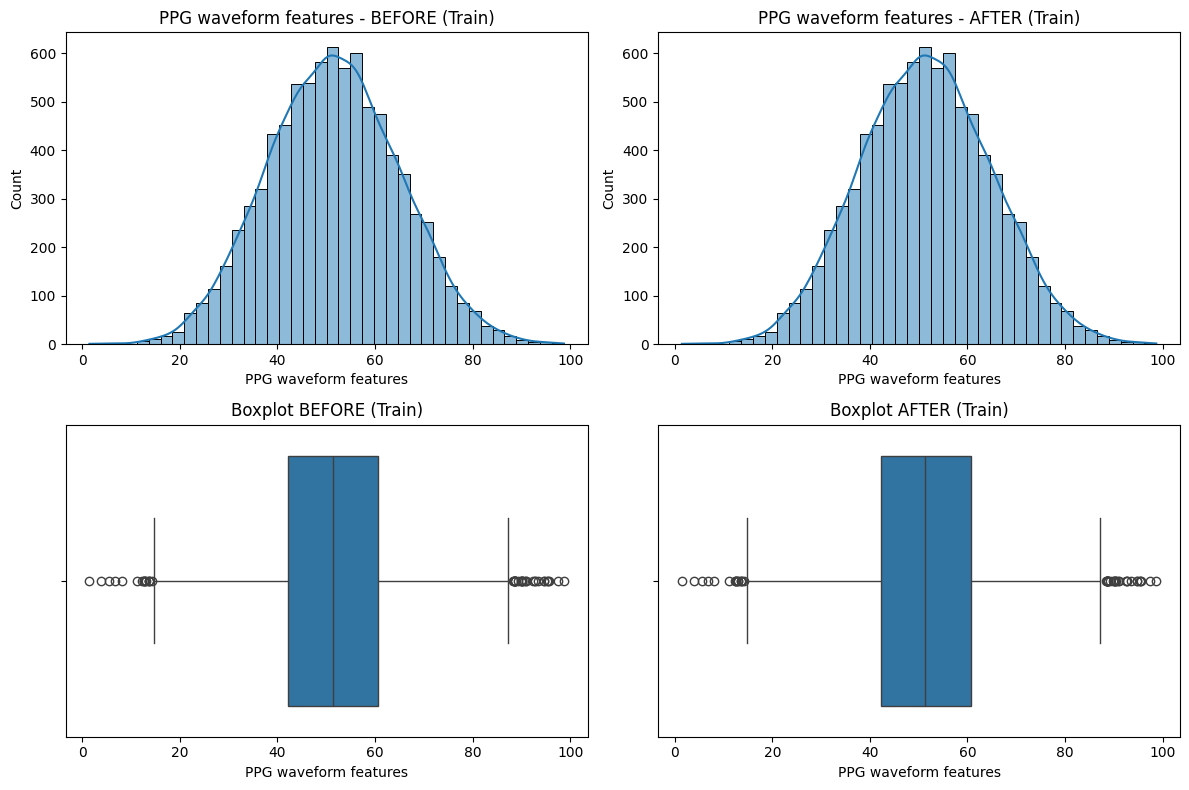

Normality BEFORE (p=0.0054) → not normal
Normality AFTER  (p=0.0054) → not normal
------------------------------------------------------------

 ***** Signal Quality Index (SD method) *****
Train outliers BEFORE: lower=10, upper=16
Soft bounds: [27.230, 68.877]
Train outliers AFTER: lower=9, upper=13


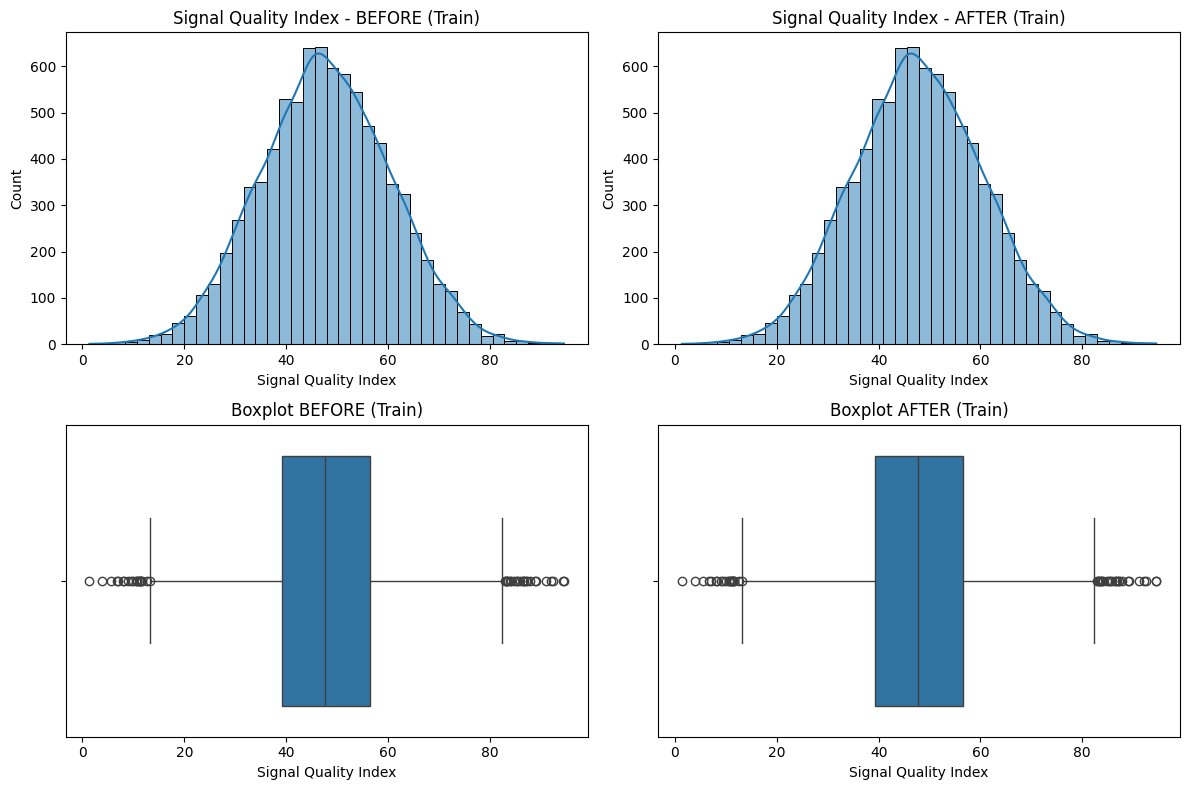

Normality BEFORE (p=0.1857) → normal
Normality AFTER  (p=0.1857) → normal
------------------------------------------------------------

 ***** Respiratory effort (SD method) *****
Train outliers BEFORE: lower=16, upper=9
Soft bounds: [30.785, 68.468]
Train outliers AFTER: lower=12, upper=6


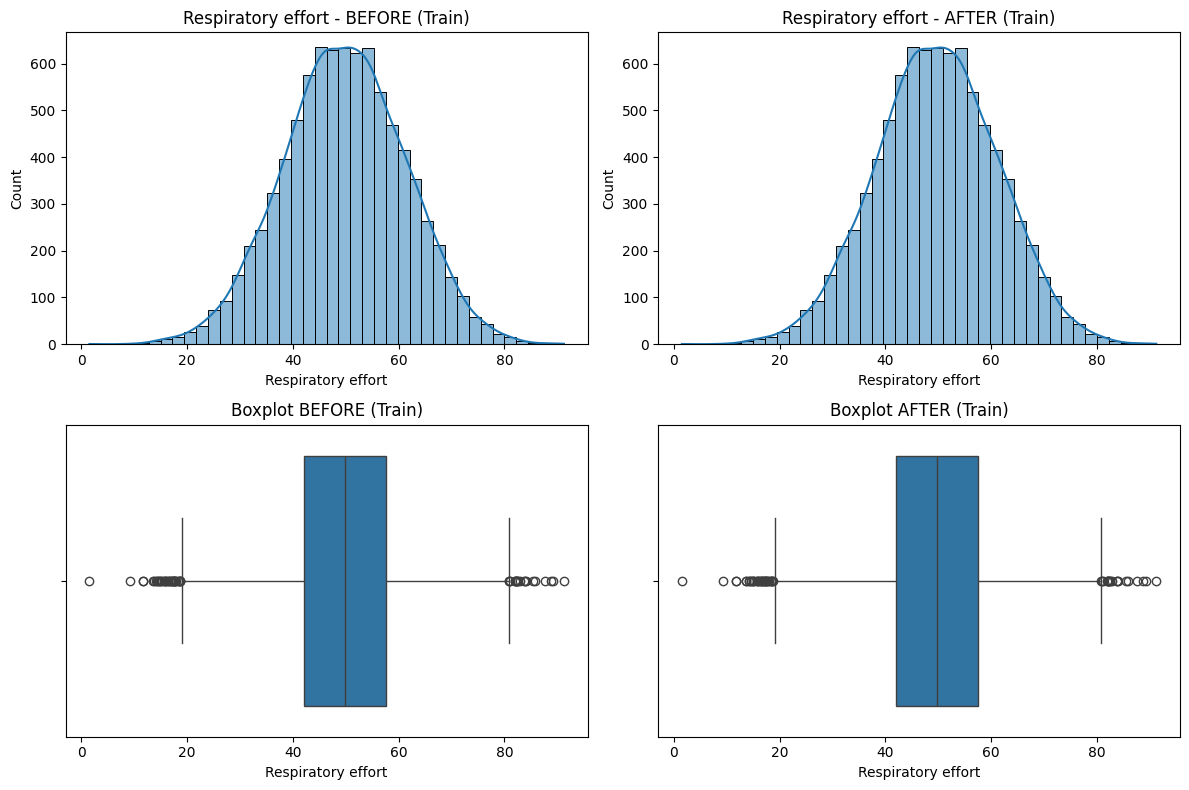

Normality BEFORE (p=0.2251) → normal
Normality AFTER  (p=0.2251) → normal
------------------------------------------------------------

 ***** O₂ extraction ratio (IQR method) *****
Train outliers BEFORE: lower=0, upper=0
Soft bounds: [0.205, 0.295]
Train outliers AFTER: lower=0, upper=0


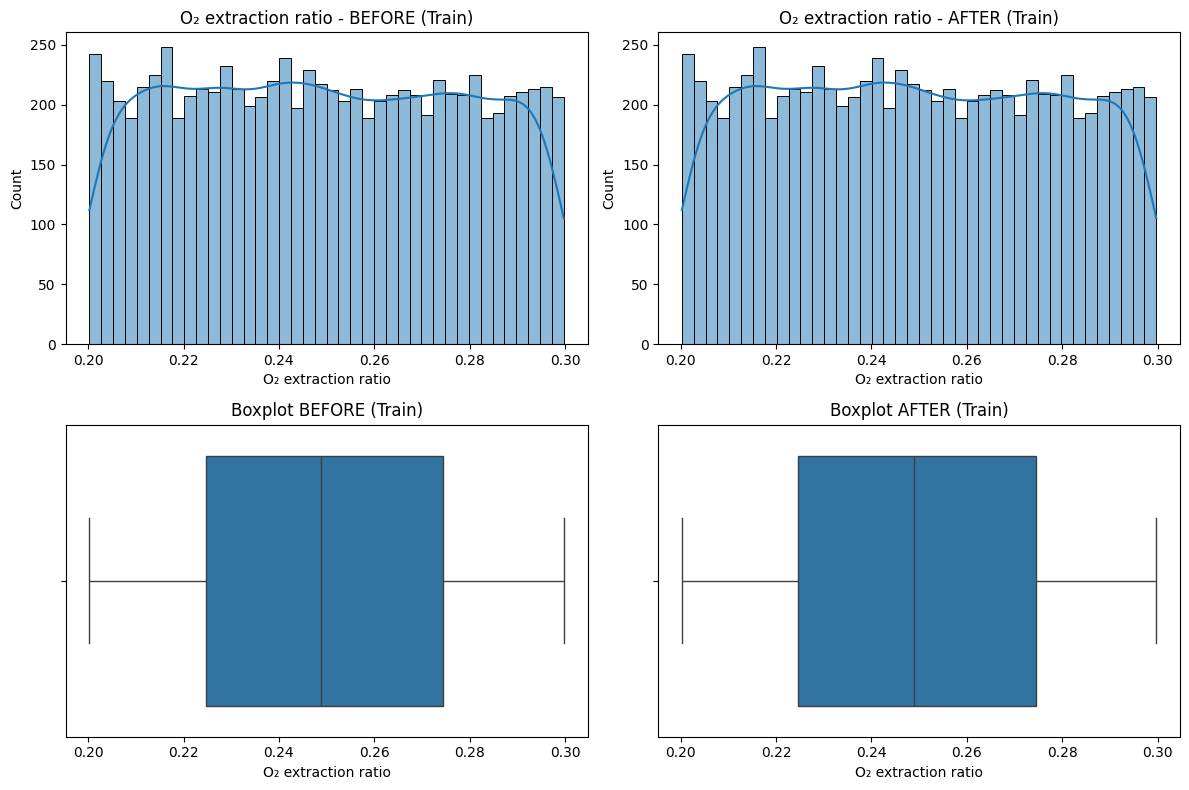

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** SNR (IQR method) *****
Train outliers BEFORE: lower=0, upper=0
Soft bounds: [20.993, 38.933]
Train outliers AFTER: lower=0, upper=0


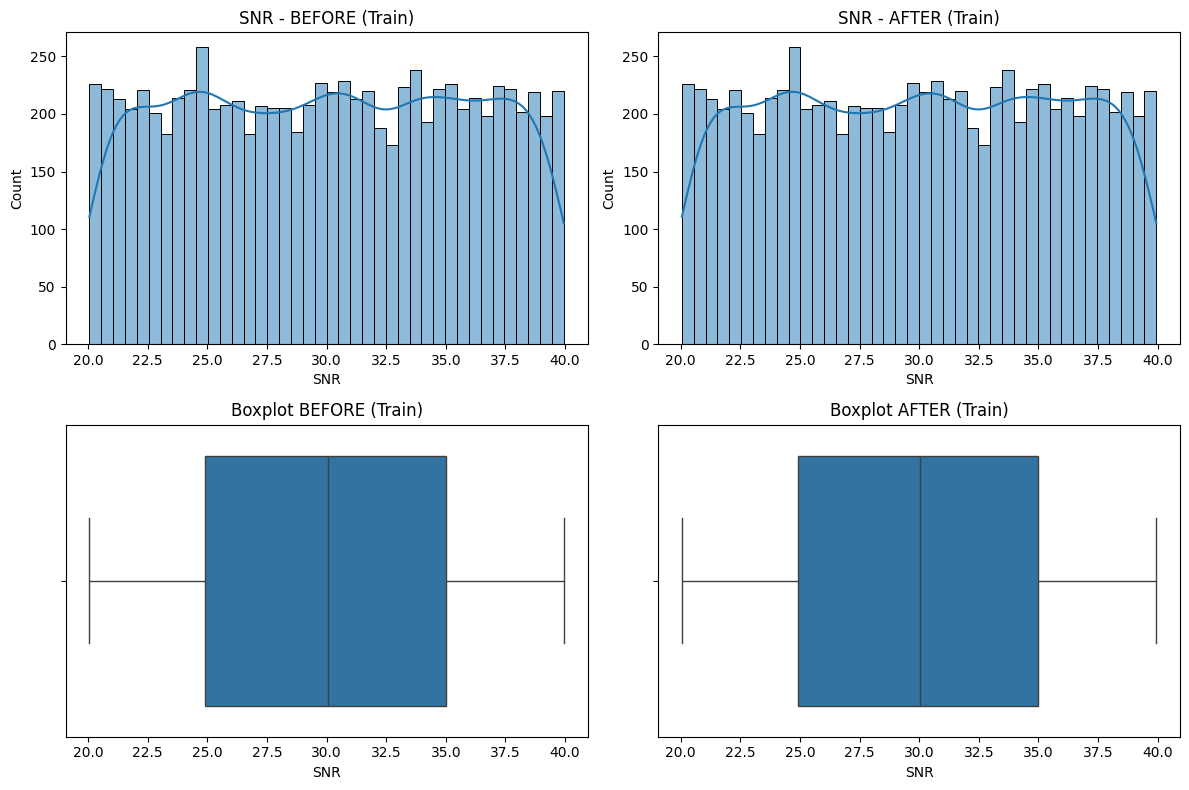

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** latitude (IQR method) *****
Train outliers BEFORE: lower=47, upper=0
Soft bounds: [-20.253, 54.844]
Train outliers AFTER: lower=47, upper=0


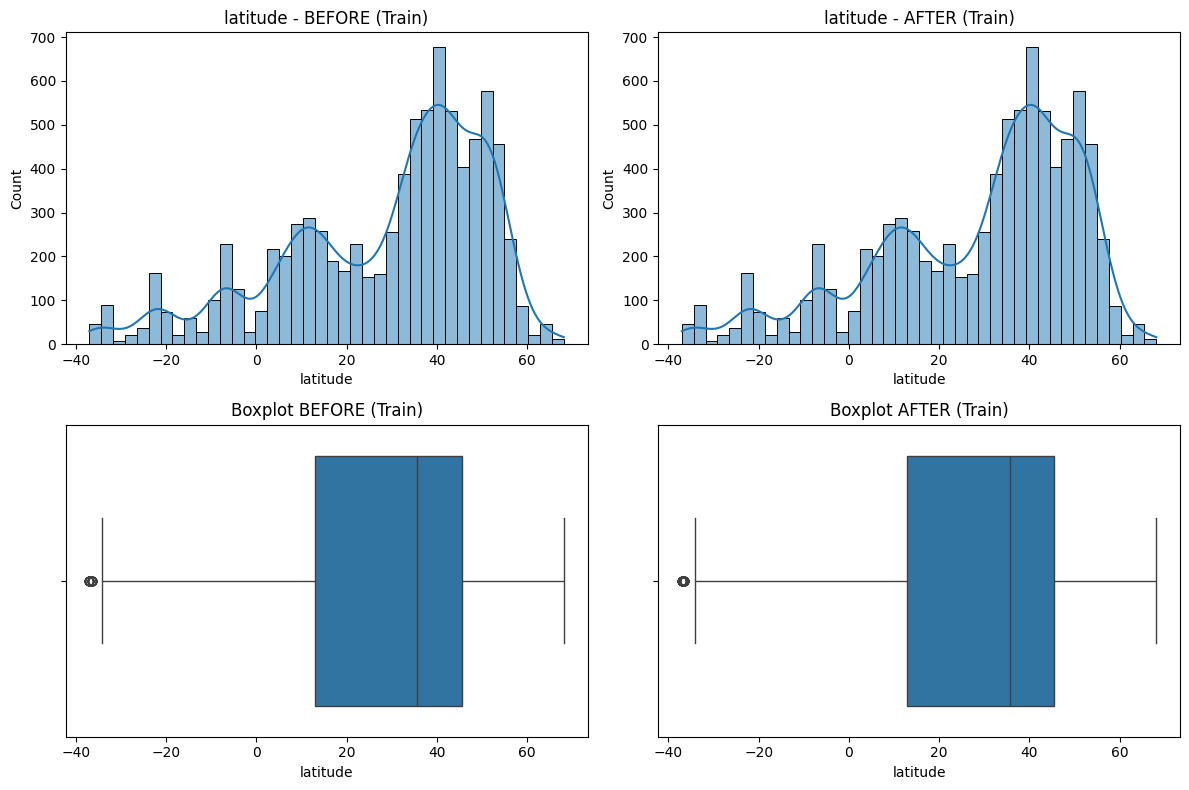

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------

 ***** longitude (IQR method) *****
Train outliers BEFORE: lower=0, upper=0
Soft bounds: [-103.429, 124.370]
Train outliers AFTER: lower=0, upper=0


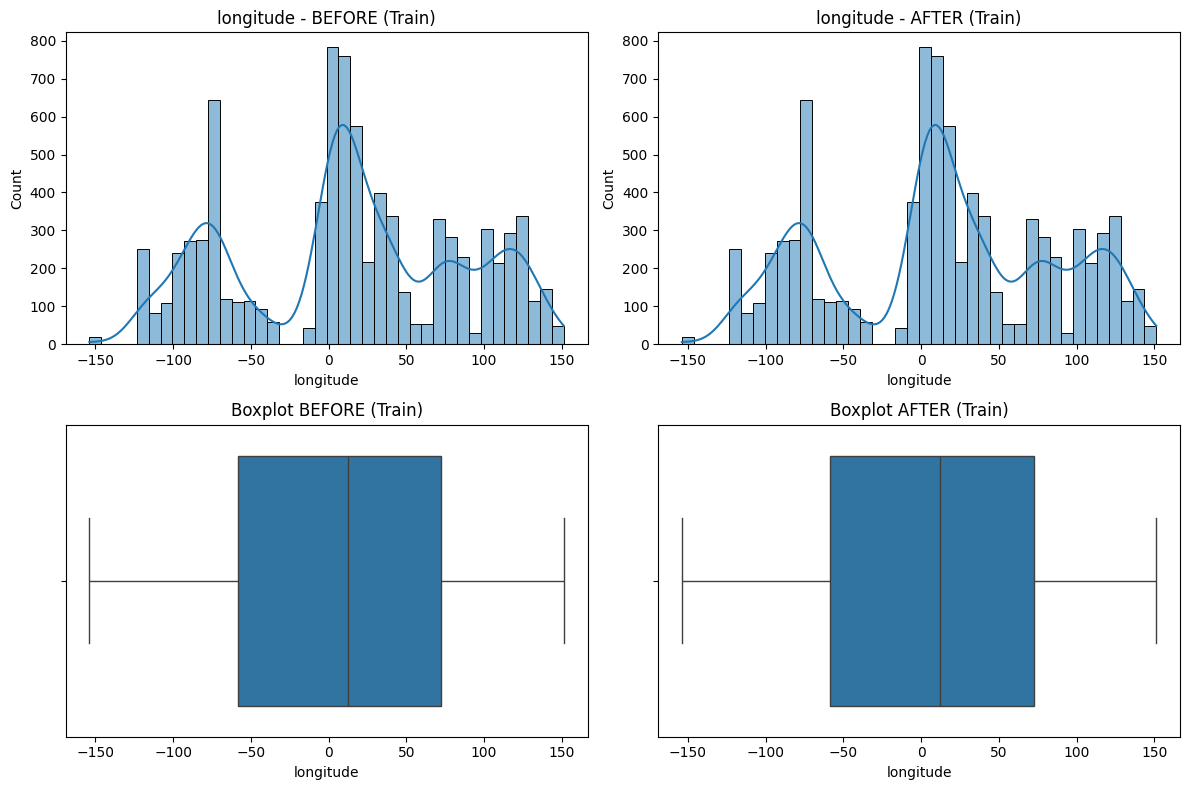

Normality BEFORE (p=0.0000) → not normal
Normality AFTER  (p=0.0000) → not normal
------------------------------------------------------------


In [18]:
def compute_bounds(series, method, sd_threshold=3, lower_pct=0.05, upper_pct=0.95):
    """Compute lower and upper clipping bounds based on method."""
    data = series.dropna()

    if method == 'IQR':
        Q1, Q3 = data.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_hard = Q1 - 1.5 * IQR
        upper_hard = Q3 + 1.5 * IQR
    elif method == 'SD':
        mean, std = data.mean(), data.std(ddof=1)
        lower_hard = mean - sd_threshold * std
        upper_hard = mean + sd_threshold * std
    else:
        raise ValueError("method must be 'IQR' or 'SD'")

    lower_soft, upper_soft = data.quantile([lower_pct, upper_pct])
    return lower_hard, upper_hard, lower_soft, upper_soft


def winsorize_series(series, lower_soft, upper_soft, softness=0.95):
    """Apply winsorization on a pandas series."""
    s = series.copy()
    s.loc[s < lower_soft] = lower_soft + softness * (s[s < lower_soft] - lower_soft)
    s.loc[s > upper_soft] = upper_soft - softness * (upper_soft - s[s > upper_soft])
    return s



#df_winsor = df.copy()
X_train_winsor = X_train.copy()
X_test_winsor  = X_test.copy()

for col, method in WINSOR_METHODS.items():
    
    print(f"\n ***** {col} ({method} method) *****")
    
    # COMPUTE BOUNDS ON TRAIN ONLY
    lower_hard, upper_hard, lower_soft, upper_soft = compute_bounds(X_train_winsor[col], method)
    
    # OUTLIER COUNTS BEFORE
    before_low  = (X_train_winsor[col] < lower_hard).sum()
    before_high = (X_train_winsor[col] > upper_hard).sum()
    print(f"Train outliers BEFORE: lower={before_low}, upper={before_high}")
    print(f"Soft bounds: [{lower_soft:.3f}, {upper_soft:.3f}]")

    # APPLY TO TRAIN
    X_train_winsor[col] = winsorize_series(X_train_winsor[col], lower_soft, upper_soft)

    # OUTLIER COUNTS AFTER
    after_low  = (X_train_winsor[col] < lower_hard).sum()
    after_high = (X_train_winsor[col] > upper_hard).sum()
    print(f"Train outliers AFTER: lower={after_low}, upper={after_high}")

    # VISUALIZATION
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    sns.histplot(X_train_winsor[col], bins=40, kde=True, ax=axes[0,0])
    axes[0,0].set_title(f"{col} - BEFORE (Train)")

    sns.histplot(X_train_winsor[col], bins=40, kde=True, ax=axes[0,1])
    axes[0,1].set_title(f"{col} - AFTER (Train)")

    sns.boxplot(x=X_train_winsor[col], ax=axes[1,0])
    axes[1,0].set_title("Boxplot BEFORE (Train)")

    sns.boxplot(x=X_train_winsor[col], ax=axes[1,1])
    axes[1,1].set_title("Boxplot AFTER (Train)")

    plt.tight_layout()
    plt.show()

    # NORMALITY TEST
    p_before = normaltest(X_train_winsor[col].dropna()).pvalue
    p_after  = normaltest(X_train_winsor[col].dropna()).pvalue

    print(f"Normality BEFORE (p={p_before:.4f}) → {'normal' if p_before>0.05 else 'not normal'}")
    print(f"Normality AFTER  (p={p_after:.4f}) → {'normal' if p_after>0.05 else 'not normal'}")
    print("-" * 60)

We can see that there are still outliers but at the same time we work with medical data. they are correct medical records which falls into the right range. Changing drastically the values may affect the ml. Therefore we used soft winsorization which soften the extremes just a little bit. 

### Missing values

In [19]:
nan_report = X_train_winsor.isna().sum()
nan_report = nan_report[nan_report > 0].sort_values(ascending=False)
nan_report

code    10
dtype: int64

In train data there are 10 missing values in column code. In this example we just focus on code column but in preprocessor we will implement imputer for every column.

In [20]:
imputer_code = SimpleImputer(strategy="most_frequent")

before = X_train_winsor['code'].isna().sum()
print("Before:", before)

# Fit only on train, and flatten result to 1D
X_train_winsor['code'] = imputer_code.fit_transform(X_train_winsor[['code']]).ravel()

after = X_train_winsor['code'].isna().sum()
print("After:", after)

print("Imputed value:", imputer_code.statistics_[0])

Before: 10
After: 0
Imputed value: US


The code was filled with value US because US is the most frequent one.

We do the same for test data

In [21]:
before = X_test_winsor['code'].isna().sum()
print("\nTest Before:", before)
X_test_winsor['code'] = imputer_code.transform(X_test_winsor[['code']]).ravel()
after = X_test_winsor['code'].isna().sum()
print("Test After:", after)


Test Before: 5
Test After: 0


### Encoding

Our categorical data in dataset are only **code** and **station**.

### One hot encoding

We apply one-hot encoding to the categorical column code.
This converts each unique category into a separate binary feature (0/1). 

In [22]:
data = X_train_winsor['code']

# create an object of the OneHotEncoder
encoder = ce.OneHotEncoder(cols=['code'], handle_unknown='ignore')

# fit and transform and you will get the encoded data
encoded_data = encoder.fit_transform(data)

In [23]:
encoded_data.shape

(8450, 107)

In [24]:
X_train_winsor['code'].nunique()

107

In [25]:
# Adding the encoded data into dataset
X_train_winsor = X_train_winsor.drop(columns=['code'])
X_train_winsor = pd.concat([X_train_winsor, encoded_data], axis=1)

In [26]:
X_train_winsor.columns.tolist()

['SPO2',
 'HR',
 'PI',
 'RR',
 'ETCO2',
 'FIO2',
 'PRV',
 'BP',
 'ST',
 'MAI',
 'PVI',
 'Hb level',
 'SV',
 'CO',
 'Blood Flow Index',
 'PPG waveform features',
 'Signal Quality Index',
 'Respiratory effort',
 'O₂ extraction ratio',
 'SNR',
 'latitude',
 'longitude',
 'station',
 'code_1',
 'code_2',
 'code_3',
 'code_4',
 'code_5',
 'code_6',
 'code_7',
 'code_8',
 'code_9',
 'code_10',
 'code_11',
 'code_12',
 'code_13',
 'code_14',
 'code_15',
 'code_16',
 'code_17',
 'code_18',
 'code_19',
 'code_20',
 'code_21',
 'code_22',
 'code_23',
 'code_24',
 'code_25',
 'code_26',
 'code_27',
 'code_28',
 'code_29',
 'code_30',
 'code_31',
 'code_32',
 'code_33',
 'code_34',
 'code_35',
 'code_36',
 'code_37',
 'code_38',
 'code_39',
 'code_40',
 'code_41',
 'code_42',
 'code_43',
 'code_44',
 'code_45',
 'code_46',
 'code_47',
 'code_48',
 'code_49',
 'code_50',
 'code_51',
 'code_52',
 'code_53',
 'code_54',
 'code_55',
 'code_56',
 'code_57',
 'code_58',
 'code_59',
 'code_60',
 'code_61

- The training data contains **107 unique categories**
- After encoding, we obtain a matrix of shape **(8450, 107)**
- Each category becomes its own column → therefore 107 encoded features
- Plus other columns (features)

In [27]:
df['code'].nunique()

107

In [28]:
data = X_test_winsor[['code']]

# create an object of the OneHotEncoder
ce_OHE = ce.OneHotEncoder(cols=['code'], handle_unknown='ignore')

# fit and transform and you will get the encoded data
encoded_data_test = encoder.transform(X_test_winsor[['code']])

In [29]:
encoded_data_test.shape

(3622, 107)

In [30]:
X_test_winsor.nunique()

SPO2                     3607
HR                       3607
PI                       3607
RR                       3607
ETCO2                    3607
FIO2                     3607
PRV                      3607
BP                       3607
ST                       3607
MAI                      3607
PVI                      3607
Hb level                 3607
SV                       3607
CO                       3607
Blood Flow Index         3607
PPG waveform features    3607
Signal Quality Index     3607
Respiratory effort       3607
O₂ extraction ratio      3607
SNR                      3607
latitude                  551
longitude                 551
code                      106
station                   551
dtype: int64

In [31]:
# Adding the encoded data into dataset
X_test_winsor = X_test_winsor.drop(columns=['code'])
X_test_winsor = pd.concat([X_test_winsor, encoded_data], axis=1)

When we count the unique values per the whole dataset we can see that train data consist all 107 categories. However test data lacks one category. This is expected and normal. Not all categories must appear in test data.
What matters is that the encoder learns all possible categories from the training set.

We use this encoder because:
- High cardinality (too many values 500+)
- One hot encoding would create too many sparse columns (we already have)

### Leave one out encoding

Leave one out encoder requires the target variable y when fitting. 

**train set**

In [32]:
X_train_cat = X_train_winsor[['station']]
y_train_cat = y_train

loo = ce.LeaveOneOutEncoder(cols=['station'], handle_unknown='ignore')
encoded_train = loo.fit_transform(X_train_cat, y_train_cat)

# encoded_train is a DataFrame with 1 encoded column (station)
print(encoded_train.head())
print(encoded_train.shape)

       station
6980  0.444444
9522  0.750000
3364  0.600000
2179  0.750000
3056  0.900000
(8450, 1)


In [33]:
X_train_winsor['station'] = encoded_train

In [34]:
X_train_winsor['station'].head()

6980    0.444444
9522    0.750000
3364    0.600000
2179    0.750000
3056    0.900000
Name: station, dtype: float64

**test set**

In [35]:
X_test_cat = X_test_winsor[['station']]
encoded_test = loo.transform(X_test_cat)

print(encoded_test.head())
print(encoded_test.shape)

        station
5445   0.647059
9571   0.594595
10250  0.588235
1638   0.555556
1427   0.571429
(12072, 1)


### Transformers

**Power Transformer**
Used when data are skewed
We want to improve normal distribution

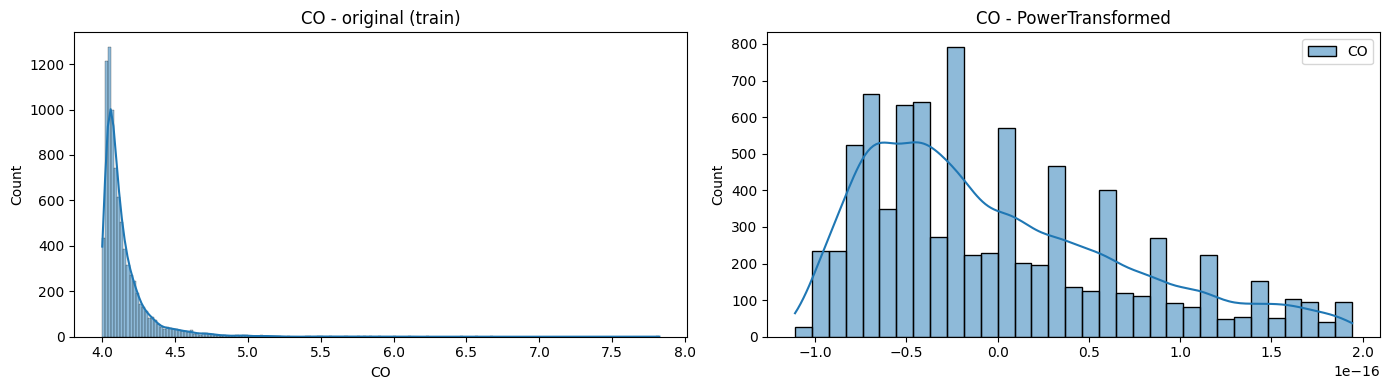

In [36]:
col = "CO"

# ---- Before transformer ----
fig, axes = plt.subplots(1,2, figsize=(14,4))
sns.histplot(X_train_winsor[col], kde=True, ax=axes[0])
axes[0].set_title(f"{col} - original (train)")

# ---- PowerTransformer (Yeo-Johnson) ----
pt = PowerTransformer(method='yeo-johnson')
X_train_winsor[[col]] = pt.fit_transform(X_train_winsor[[col]])
sns.histplot(X_train_winsor[[col]], kde=True, ax=axes[1])
axes[1].set_title(f"{col} - PowerTransformed")

plt.tight_layout()
plt.show()

PowerTransformer (Yeo-Johnson) improved the distribution but still left visible skewness. After application of PowerTransformer the distribution improved a lot which improved scalling and symetry.

**Quantile Transformer** Data have extreme outliers, data are bimodal...

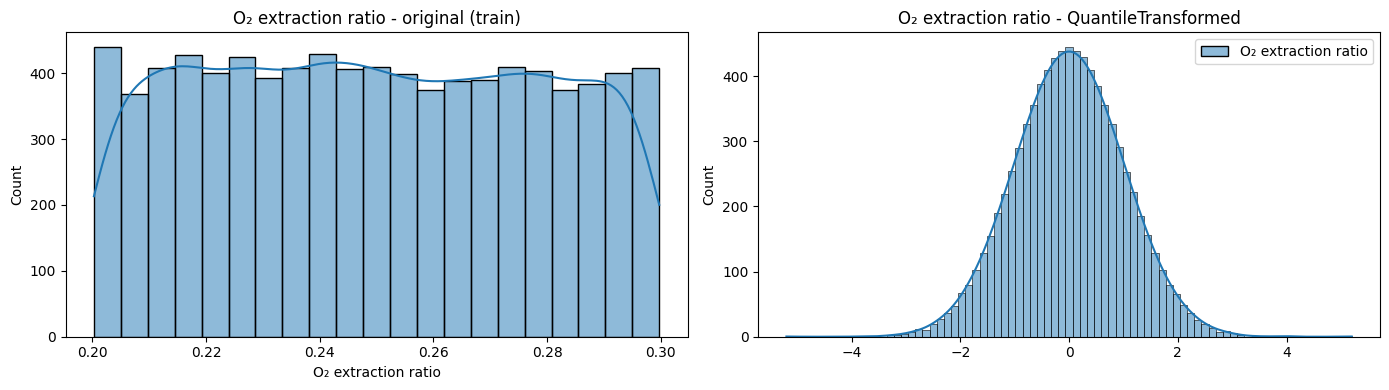

In [37]:
col = "O₂ extraction ratio"

# ---- Before transformer ----
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(X_train_winsor[col], kde=True, ax=axes[0])
axes[0].set_title(f"{col} - original (train)")

# ---- QuantileTransformer (normal output) ----
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_winsor[[col]] = qt.fit_transform(X_train_winsor[[col]])   # do NOT overwrite yet!
sns.histplot(X_train_winsor[[col]], kde=True, ax=axes[1])
axes[1].set_title(f"{col} - QuantileTransformed")

plt.tight_layout()
plt.show()

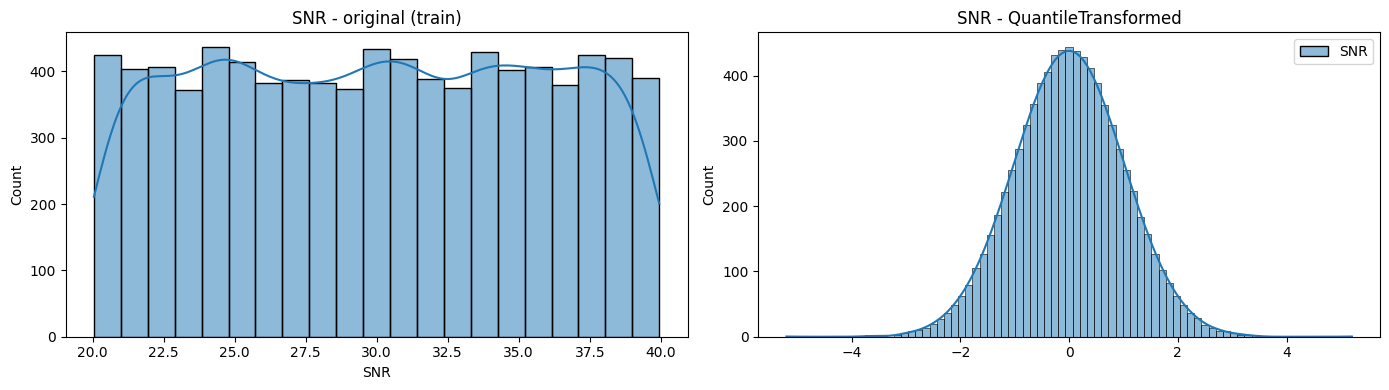

In [38]:
col = "SNR"

# ---- Before transformer ----
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(X_train_winsor[col], kde=True, ax=axes[0])
axes[0].set_title(f"{col} - original (train)")

# ---- QuantileTransformer (normal output) ----
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_winsor[[col]] = qt.fit_transform(X_train_winsor[[col]])   # do NOT overwrite yet!
sns.histplot(X_train_winsor[[col]], kde=True, ax=axes[1])
axes[1].set_title(f"{col} - QuantileTransformed")

plt.tight_layout()
plt.show()

This uniform distribution which is not ideal for the training and we need something more gaussian. Therefore we chose quantile transformer. Good for linear models which expects linearity. 

### Scalling

For each distribution we choose different scalling method based on its distribution.

For normal distributions we choose standardScaler and for data which are skewed or not symetrical the robustScaler.

For exponential distribution we choose powerTransformer + standardScaler because we want ML to learn better from the data.

In [39]:
STANDARD_NUM = [
    'HR','RR','FIO2','PRV','BP','PVI','Hb level',
    'Blood Flow Index','PPG waveform features',
    'Signal Quality Index','Respiratory effort'
]

ROBUST_NUM = [
    'SPO2','PI','ETCO2','ST','MAI','SV','latitude','longitude'
]

POWER_NUM = ['CO']

QUANT_NUM = ['O₂ extraction ratio', 'SNR']

LOW_CARD_CAT_COLS = [
    'code'        # 107 levels
]

HIGH_CARD_CAT_COLS = [
    'station'     # 552 levels
]

In [40]:
def preview_transform(original, transformed, cols, title):
    """Visualize and compare original vs transformed columns."""
    
    print(f"\n**** {title} ****")
    summary = pd.DataFrame({
        "mean_before": original[cols].mean(),
        "mean_after": transformed[cols].mean(),
        "std_before": original[cols].std(),
        "std_after": transformed[cols].std(),
        "skew_before": original[cols].skew(),
        "skew_after": transformed[cols].skew(),
        "min_before": original[cols].min(),
        "min_after": transformed[cols].min(),
        "max_before": original[cols].max(),
        "max_after": transformed[cols].max(),
    })
    display(summary.round(3))

    for col in cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        sns.histplot(original[col], bins=40, kde=True, ax=axes[0])
        axes[0].set_title(f"{col} - BEFORE")
        sns.histplot(transformed[col], bins=40, kde=True, ax=axes[1])
        axes[1].set_title(f"{col} - AFTER")
        plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        sns.boxplot(x=original[col], ax=axes[0])
        axes[0].set_title("BEFORE")
        sns.boxplot(x=transformed[col], ax=axes[1])
        axes[1].set_title("AFTER")
        plt.show()



**** StandardScaler columns ****


,mean_before,mean_after,std_before,std_after,skew_before,skew_after,min_before,min_after,max_before,max_after
HR,79.206,0.0,5.399,1.0,0.019,0.019,60.512,-3.462,99.415,3.743
RR,15.627,0.0,0.962,1.0,0.003,0.003,12.102,-3.666,19.136,3.650
FIO2,59.324,0.0,9.777,1.0,0.001,0.001,22.098,-3.808,93.276,3.473
PRV,107.727,0.0,24.466,1.0,-0.001,-0.001,22.369,-3.489,197.396,3.665
BP,103.726,-0.0,3.702,1.0,0.021,0.021,91.295,-3.358,119.487,4.257
PVI,15.435,0.0,1.204,1.0,0.023,0.023,10.173,-4.371,19.806,3.631
Hb level,15.099,0.0,0.766,1.0,-0.015,-0.015,12.092,-3.925,17.918,3.679
Blood Flow Index,51.813,0.0,12.804,1.0,-0.021,-0.021,1.521,-3.928,98.637,3.657
PPG waveform features,51.539,0.0,13.458,1.0,0.049,0.049,1.472,-3.721,98.688,3.504
Signal Quality Index,47.820,0.0,12.693,1.0,0.035,0.035,1.362,-3.661,94.541,3.681


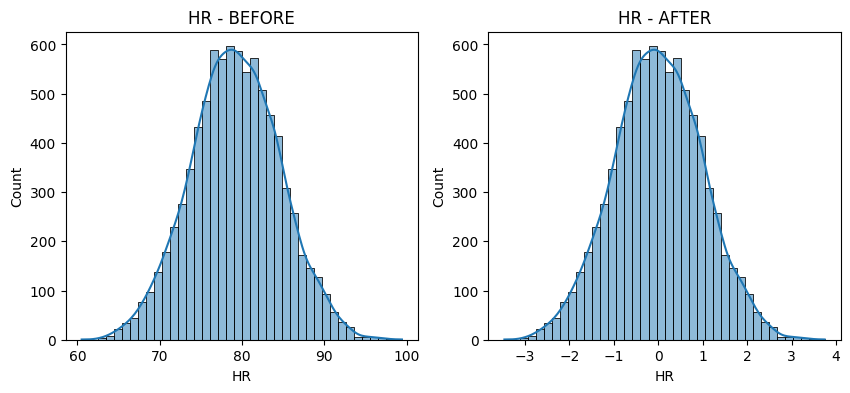

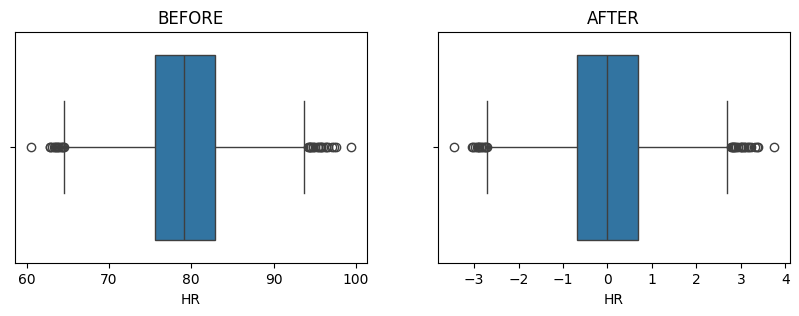

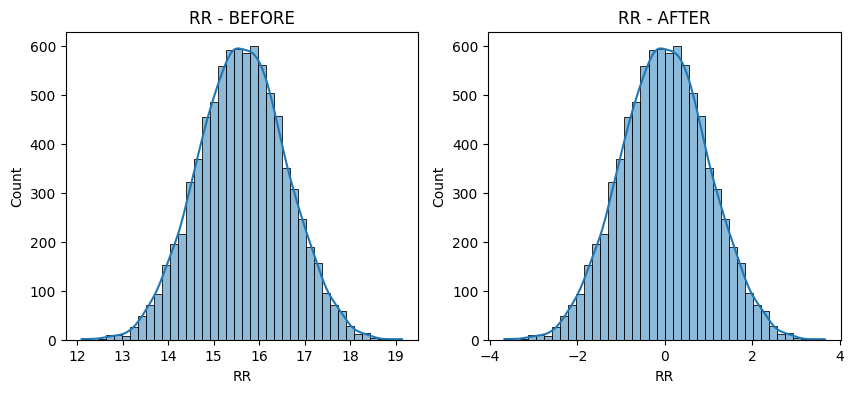

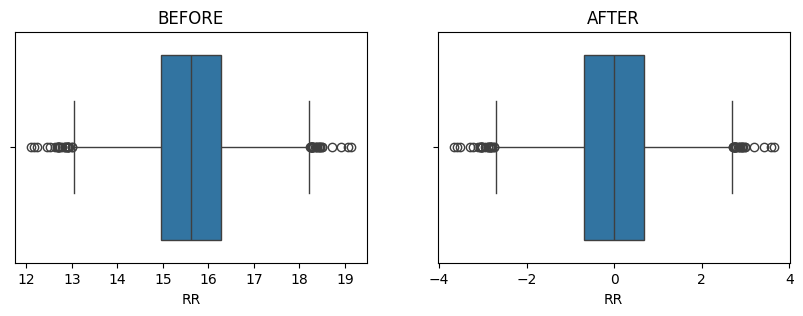

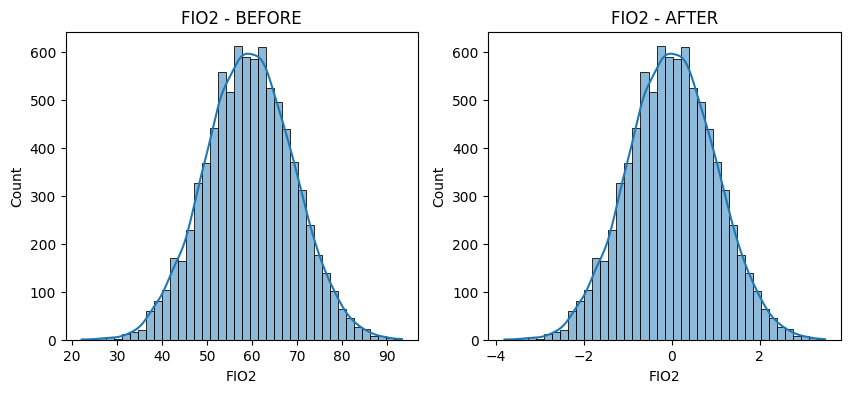

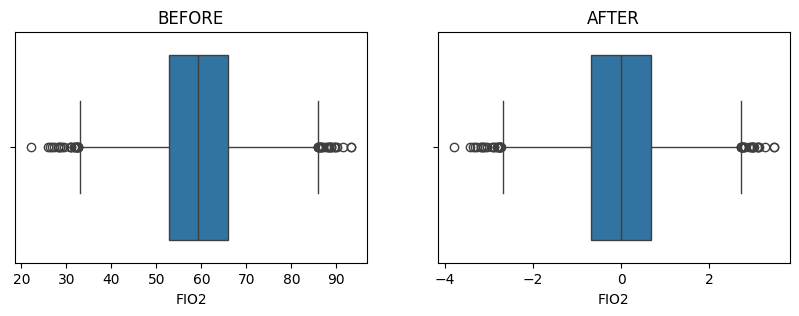

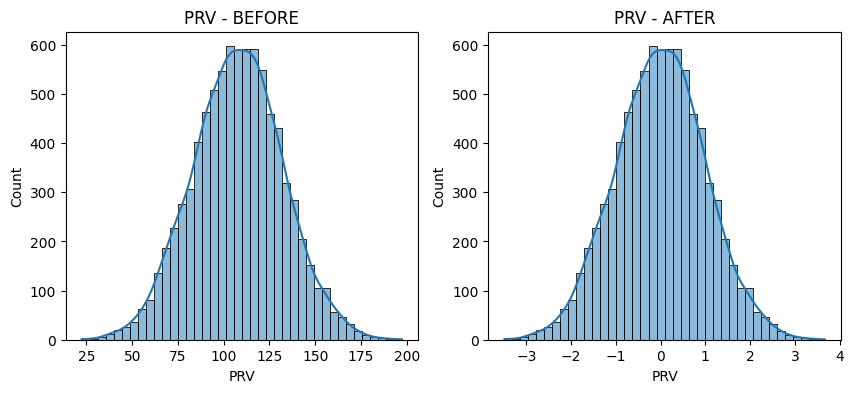

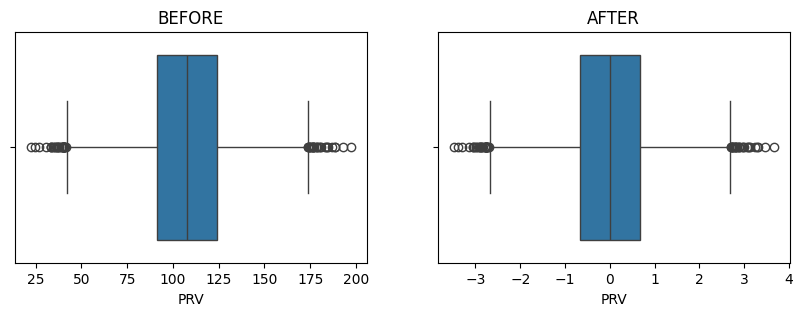

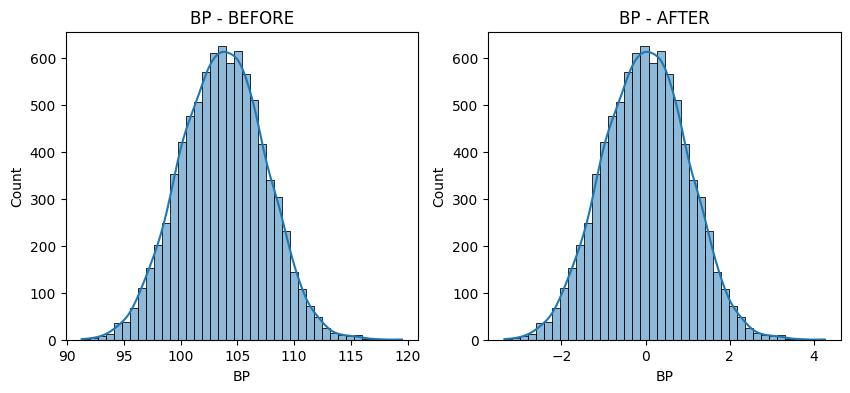

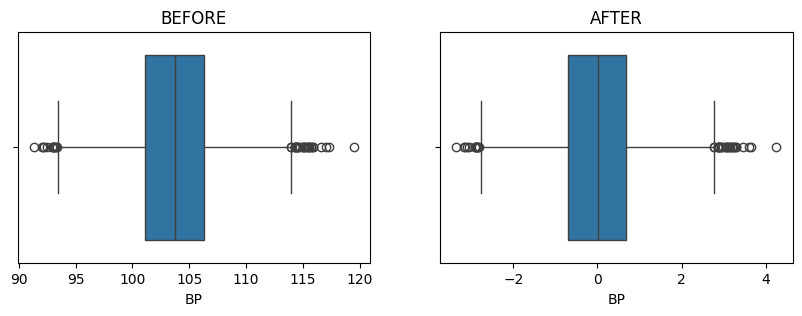

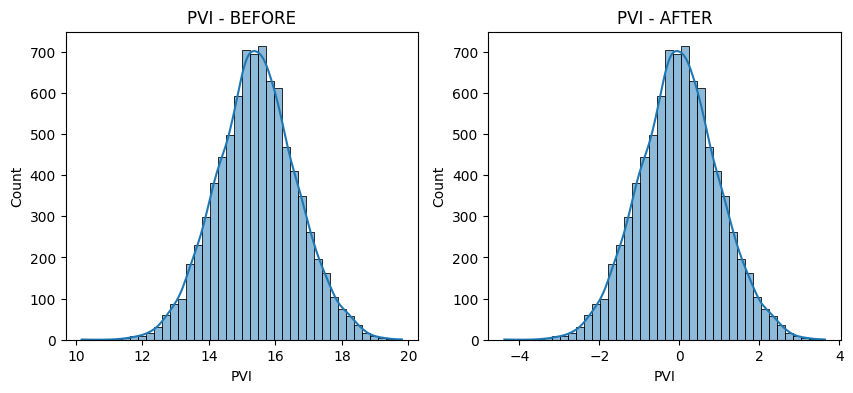

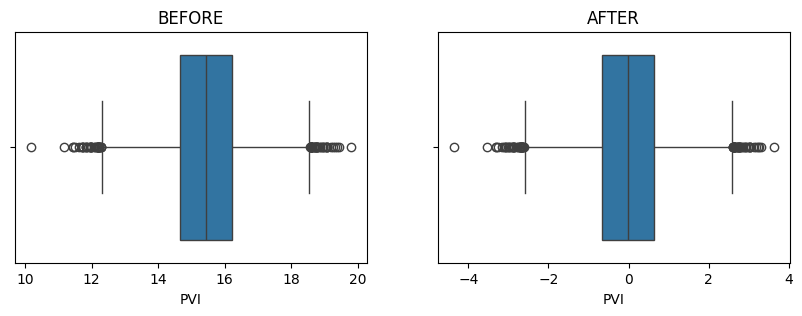

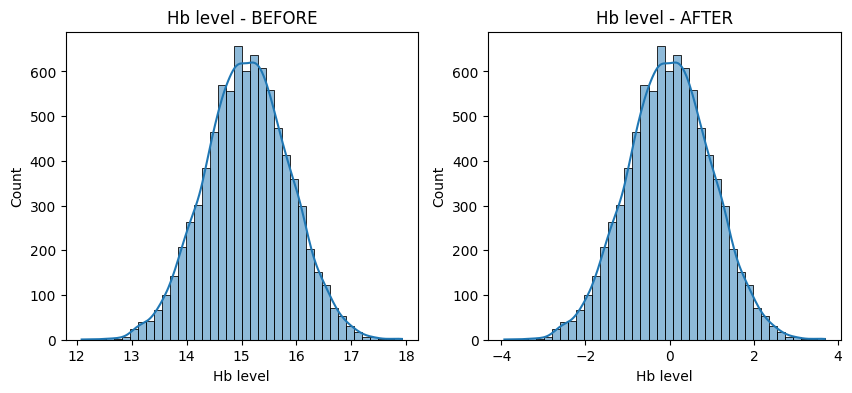

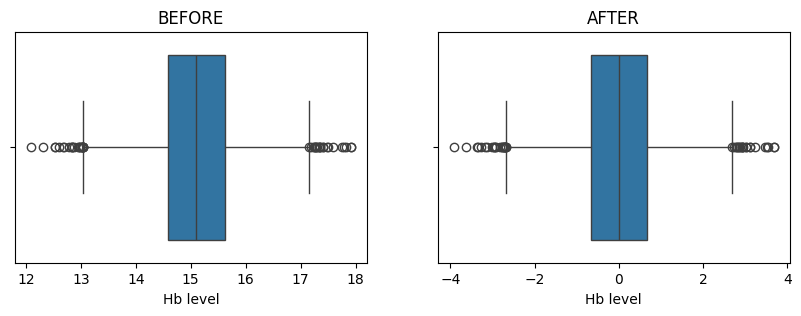

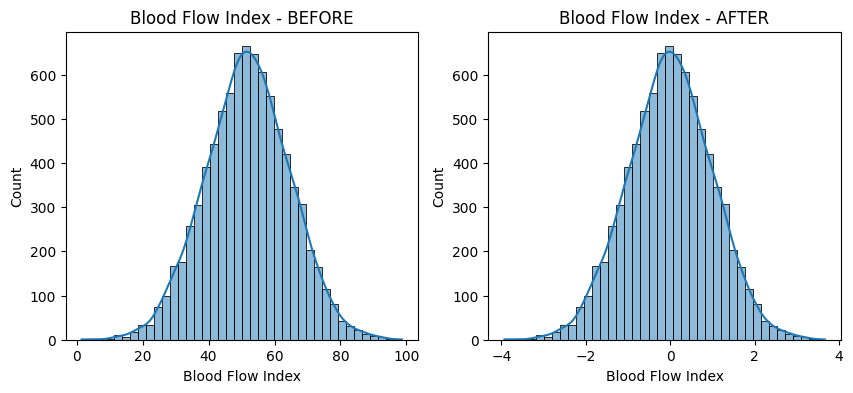

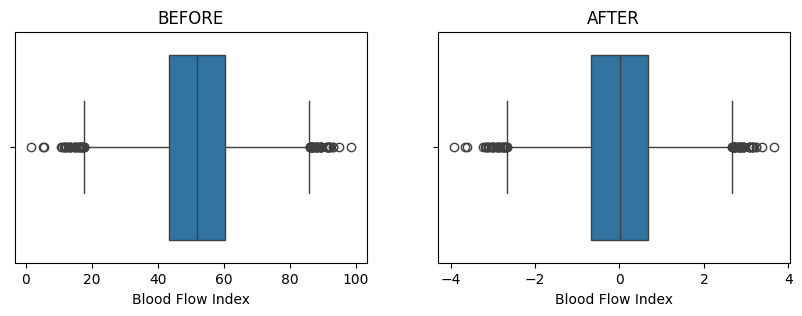

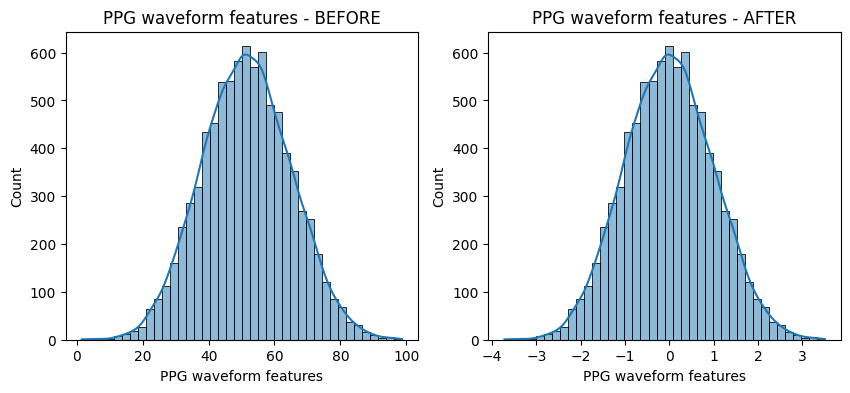

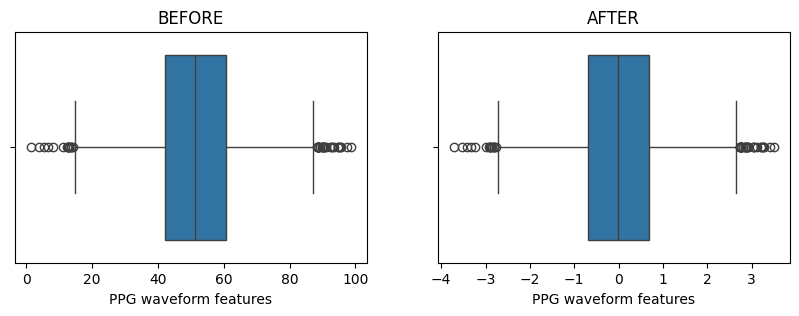

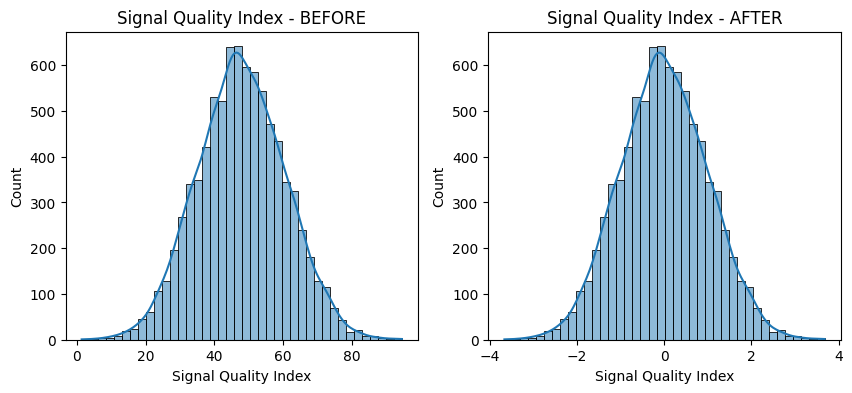

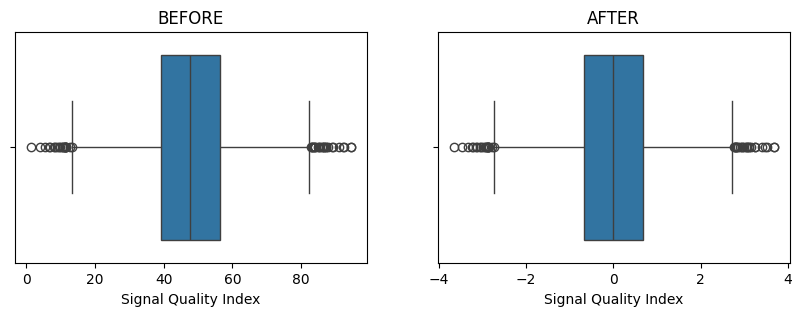

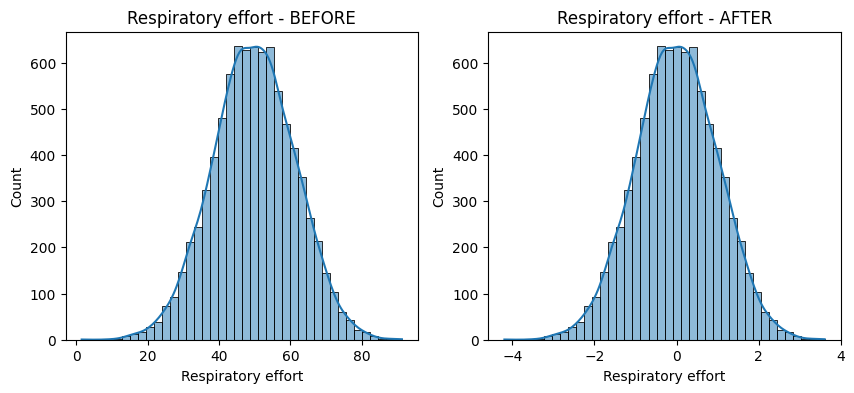

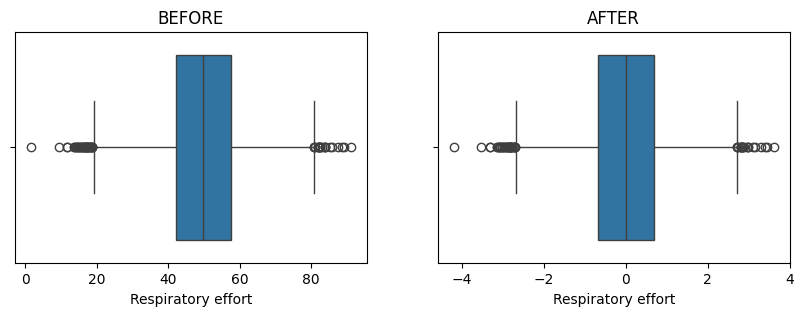


**** RobustScaler columns ****


,mean_before,mean_after,std_before,std_after,skew_before,skew_after,min_before,min_after,max_before,max_after
SPO2,97.729,-0.004,0.847,0.644,-0.127,-0.127,95.066,-2.028,99.951,1.684
PI,10.017,-0.124,3.423,0.630,-0.318,-0.318,0.759,-1.828,18.922,1.515
ETCO2,40.032,-0.027,1.197,0.788,-0.067,-0.067,35.311,-3.134,44.848,3.144
ST,35.394,0.003,0.709,0.677,0.025,0.025,33.234,-2.061,37.711,2.216
MAI,9.842,0.090,3.071,0.606,0.148,0.148,1.381,-1.580,18.461,1.790
SV,89.147,0.006,3.075,0.736,-0.118,-0.118,61.204,-6.682,99.711,2.534
latitude,28.706,-0.214,22.399,0.690,-0.886,-0.886,-37.018,-2.238,68.101,0.999
longitude,12.752,0.004,72.316,0.552,-0.091,-0.091,-153.822,-1.268,151.288,1.062


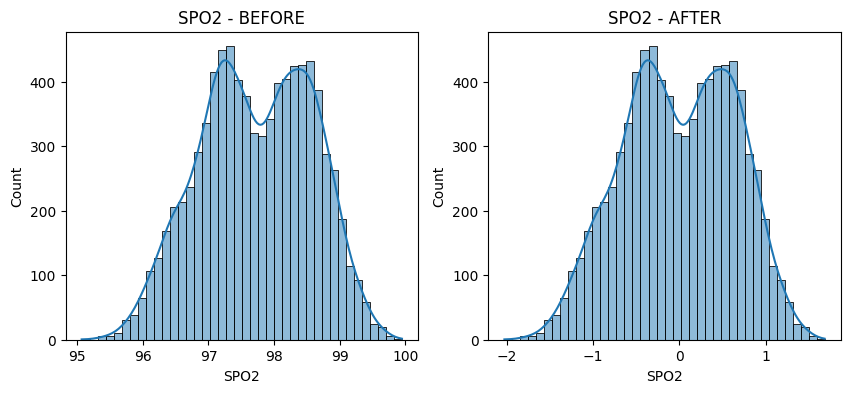

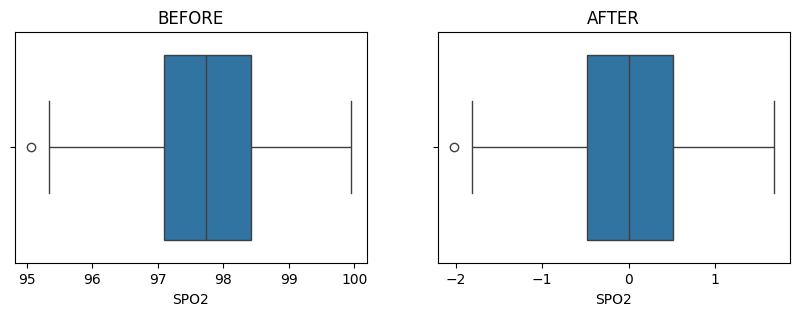

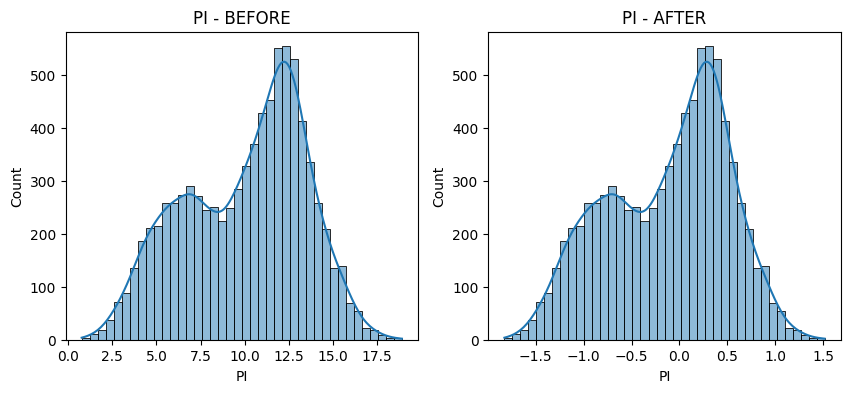

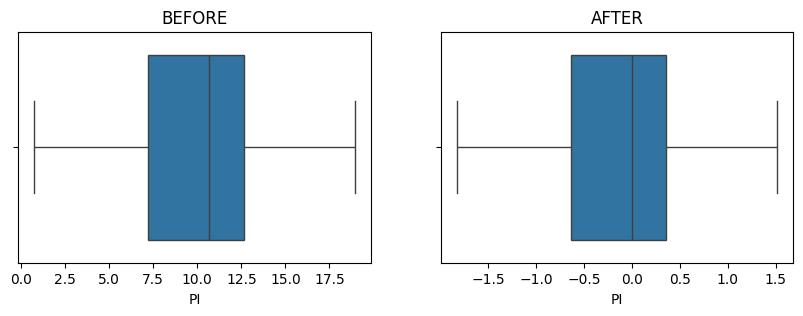

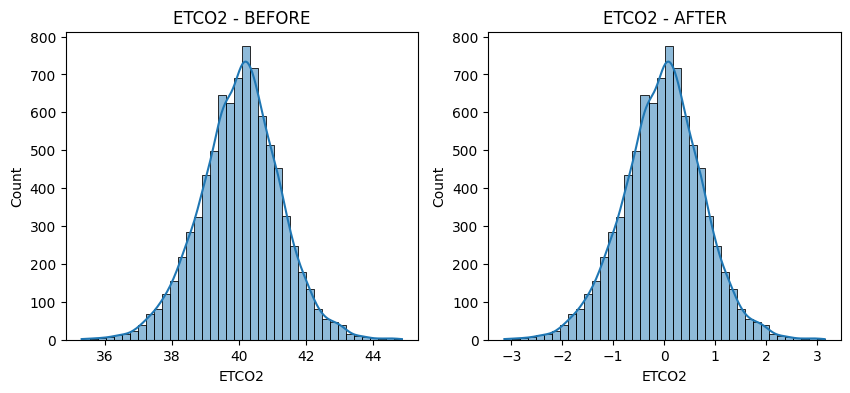

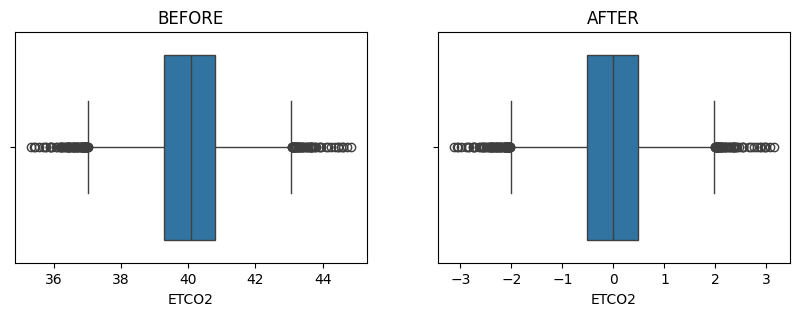

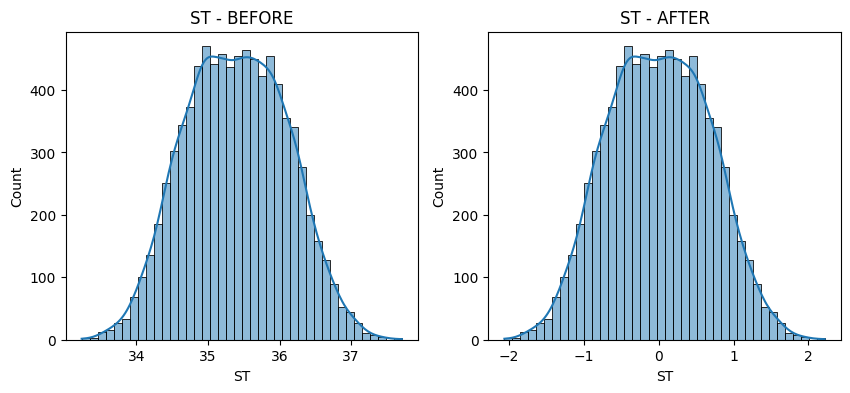

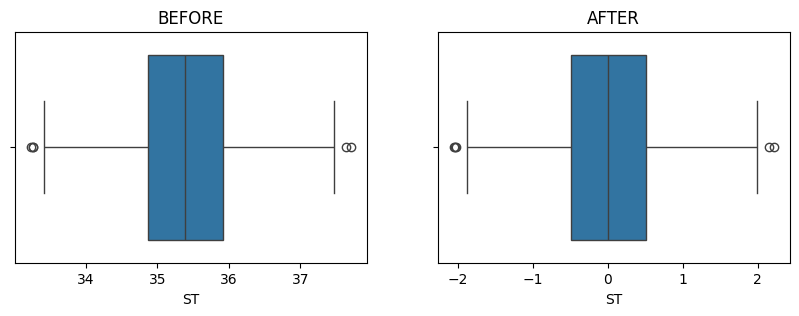

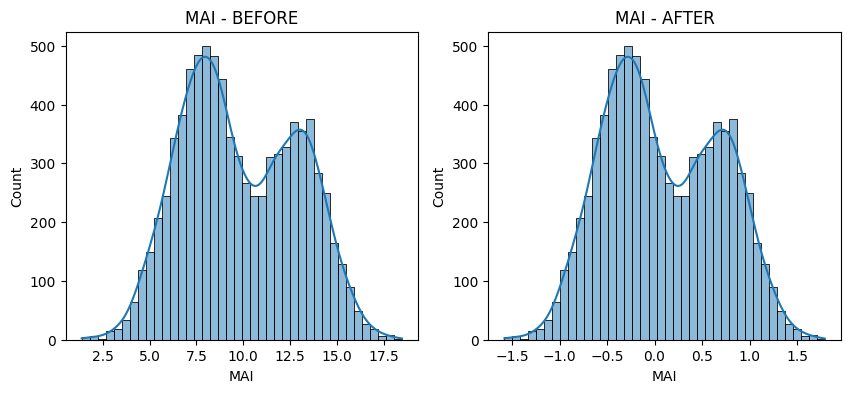

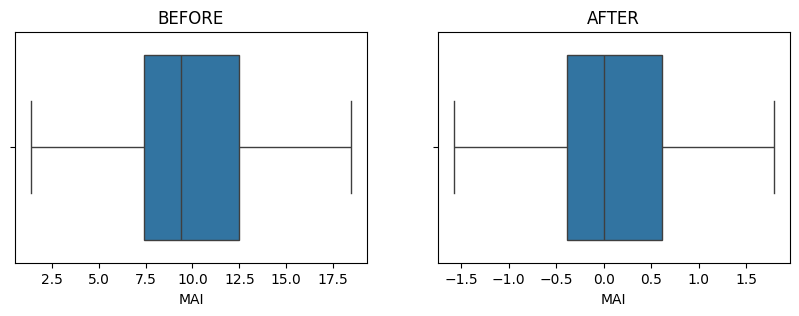

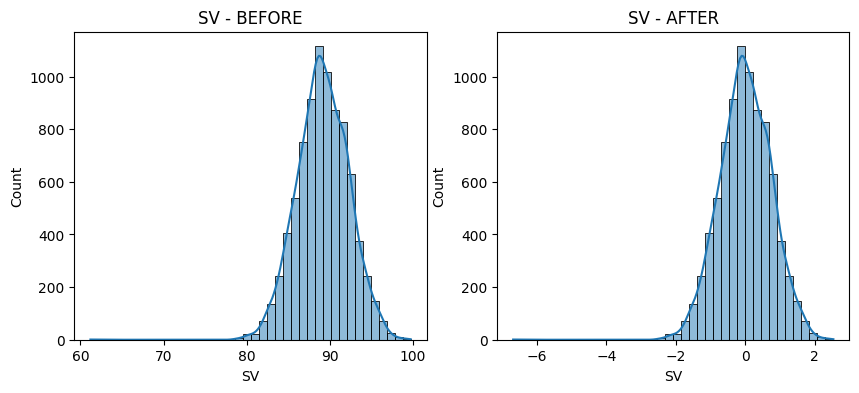

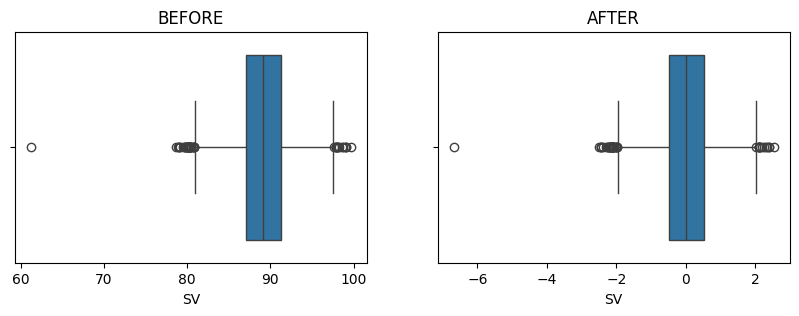

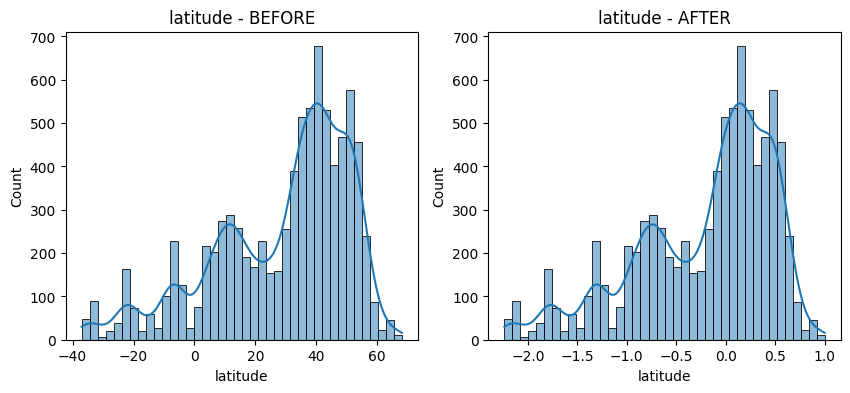

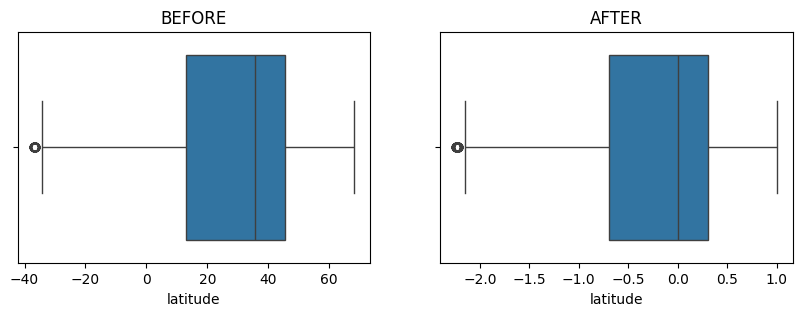

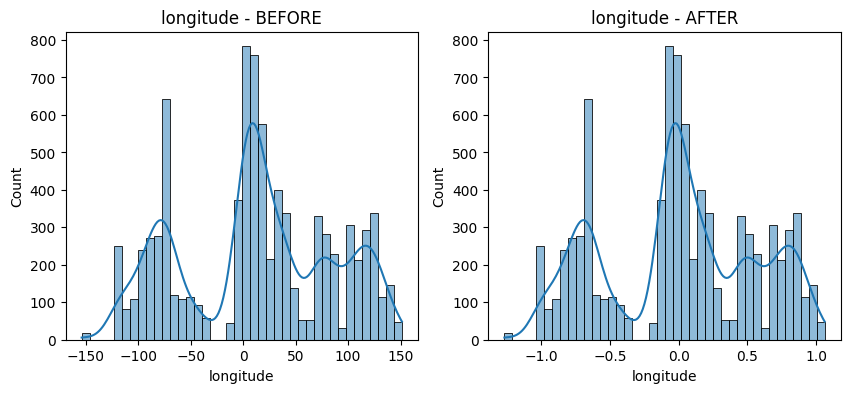

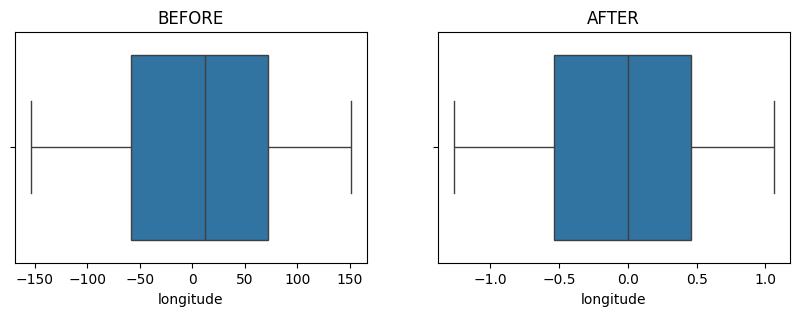


**** PowerTransformer (prev) + StandardScaler ****


,mean_before,mean_after,std_before,std_after,skew_before,skew_after,min_before,min_after,max_before,max_after
CO,-0.0,-0.0,0.0,1.0,0.0,0.811,-0.0,-1.56,0.0,2.761


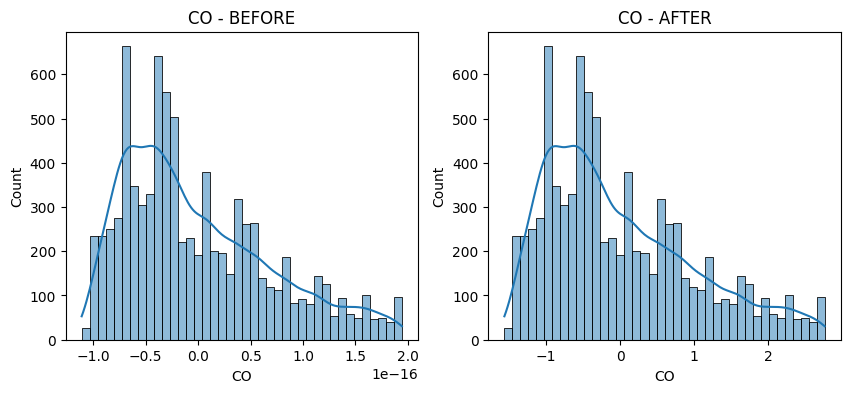

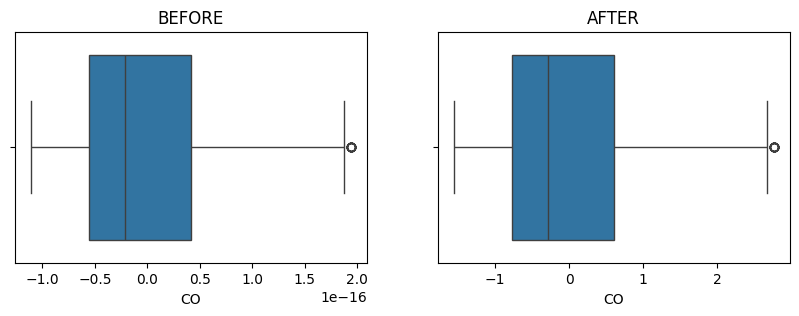


**** QuantileTransformer (prev) + StandardScaler ****


,mean_before,mean_after,std_before,std_after,skew_before,skew_after,min_before,min_after,max_before,max_after
O₂ extraction ratio,0.0,0.0,1.003,1.0,0.007,0.007,-5.199,-5.184,5.199,5.183
SNR,-0.0,-0.0,1.002,1.0,-0.003,-0.003,-5.199,-5.188,5.199,5.188


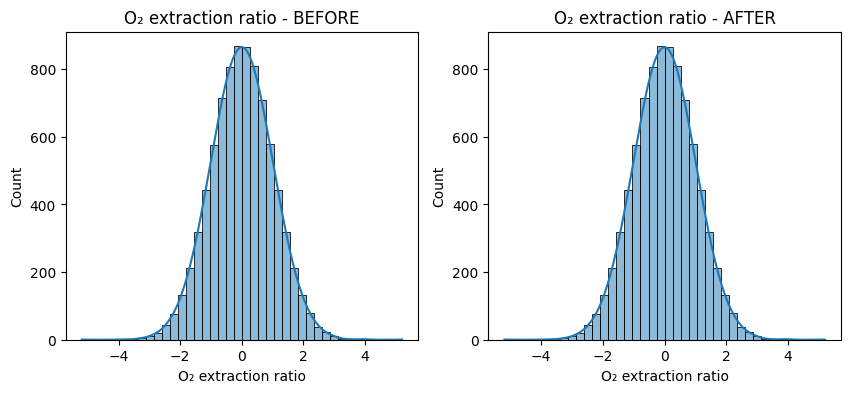

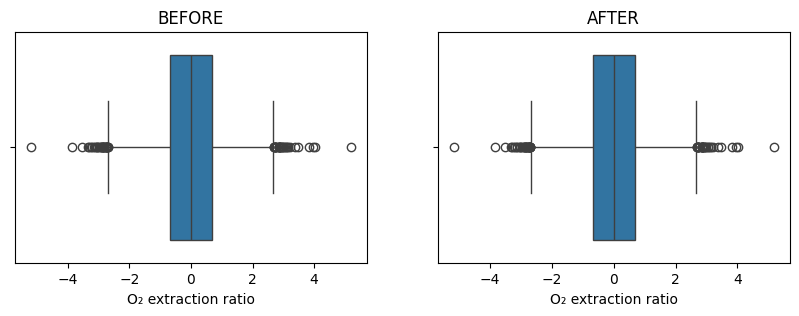

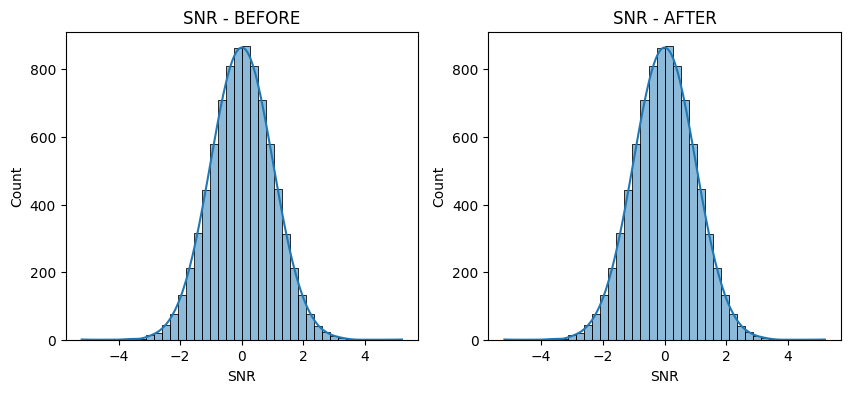

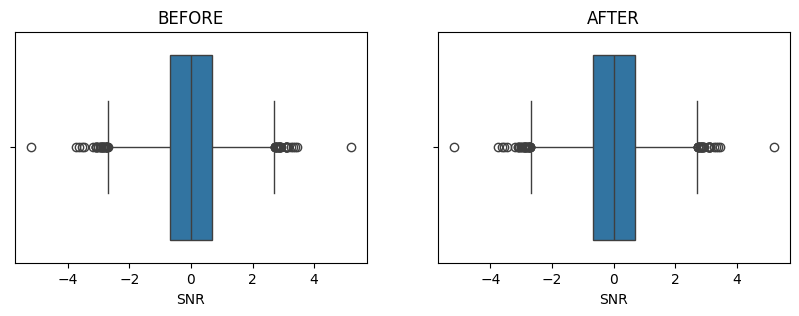

In [41]:
# Copy original feature sets AFTER winsorization AND transformer step
orig_standard = X_train_winsor[STANDARD_NUM].copy()
orig_robust   = X_train_winsor[ROBUST_NUM].copy()
orig_power    = X_train_winsor[POWER_NUM].copy()      # already PowerTransformed earlier
orig_quant    = X_train_winsor[QUANT_NUM].copy()      # already QuantileTransformed earlier

# ---- StandardScaler for NORMAL columns ----
scaler_standard = StandardScaler()
scaled_standard = scaler_standard.fit_transform(orig_standard)
trans_standard = pd.DataFrame(scaled_standard, columns=STANDARD_NUM, index=orig_standard.index)

# ---- RobustScaler for SKEWED columns ----
scaler_robust = RobustScaler()
scaled_robust = scaler_robust.fit_transform(orig_robust)
trans_robust = pd.DataFrame(scaled_robust, columns=ROBUST_NUM, index=orig_robust.index)

# ---- StandardScaler AFTER PowerTransformer (already applied earlier) ----
std_after_power = StandardScaler()
scaled_power_vals = std_after_power.fit_transform(orig_power)
trans_power = pd.DataFrame(scaled_power_vals, columns=POWER_NUM, index=orig_power.index)

# ---- StandardScaler AFTER QuantileTransformer (already applied earlier) ----
std_after_quant = StandardScaler()
scaled_quant_vals = std_after_quant.fit_transform(orig_quant)
trans_quant = pd.DataFrame(scaled_quant_vals, columns=QUANT_NUM, index=orig_quant.index)


X_train_winsor[STANDARD_NUM] = trans_standard
X_train_winsor[ROBUST_NUM]   = trans_robust
X_train_winsor[POWER_NUM]    = trans_power
X_train_winsor[QUANT_NUM]    = trans_quant

# ---- Preview transformations ----
preview_transform(orig_standard, trans_standard, STANDARD_NUM, "StandardScaler columns")
preview_transform(orig_robust, trans_robust, ROBUST_NUM, "RobustScaler columns")
preview_transform(orig_power, trans_power, POWER_NUM, "PowerTransformer (prev) + StandardScaler")
preview_transform(orig_quant, trans_quant, QUANT_NUM, "QuantileTransformer (prev) + StandardScaler")


When using standard scaler we can see thta the mean is 0 for each feature, also std equals 1. The features have became scaled and centered. The skeweness stayed the same and the distribution havent changed. 

=> table confirms that standardScaler standardized the variables correctly

When using robust scaler the data are not standardized using mean and std but with median and IQR. It is much more resistant to outliers. Keeps shape and skewness.

=> table confirms that robustScaler standardized the variables correctly

# Feature extraction

In [42]:

df_processed = X_train_cat

In [43]:
df_processed.head()

,station
6980,Middletown
9522,Dawei
3364,Southsea
2179,Paidha
3056,Jaworzno


To select right features for our data model it needs to be done with one of these techniques: applying features, doing wrapper and embedding

# Summary

We categorized the numeric features into standard, robust, and skewed groups and applied StandardScaler, RobustScaler, and PowerTransformer accordingly. This avoids over-scaling outliers and helps normalize heavily skewed variables. 

The data was split 70:30 before preprocessing to prevent leakage, and categorical variables were handled differently based on cardinality: one-hot encoding for low-cardinality features and leave-one-out encoding for high-cardinality ones.

If model performance is insufficient, one possible improvement is to replace one-hot encoding, since creating 107 binary features may lead to sparsity and suboptimal feature selection.

# 2.3

In [44]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer for outlier clipping (winsorization),
    supporting per-column method selection (IQR or SD).
    """

    def __init__(self, methods_dict, sd_threshold=3, lower_pct=0.05, upper_pct=0.95, softness=0.95):
        """
        methods_dict: dict, e.g. {"HR": "SD", "SPO2": "IQR"}
        sd_threshold: cutoff for z-score when using SD
        lower_pct, upper_pct: quantile bounds used for soft winsorization
        softness: smoothing factor (0=no smoothing, 1=full)
        """
        self.methods_dict = methods_dict
        self.sd_threshold = sd_threshold
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct
        self.softness = softness

    def fit(self, X, y=None):
        """Compute winsorization bounds from TRAIN data only."""
        X = pd.DataFrame(X).copy()
        self.bounds_ = {}

        for col, method in self.methods_dict.items():
            data = X[col].dropna()
            if len(data) < 5:
                self.bounds_[col] = None
                continue

            # Hard bounds (IQR or SD)
            if method == "IQR":
                Q1, Q3 = data.quantile([0.25, 0.75])
                IQR = Q3 - Q1
                lower_hard = Q1 - 1.5 * IQR
                upper_hard = Q3 + 1.5 * IQR

            elif method == "SD":
                mean, std = data.mean(), data.std(ddof=1)
                lower_hard = mean - self.sd_threshold * std
                upper_hard = mean + self.sd_threshold * std

            else:
                raise ValueError(f"Unknown method {method}. Use 'IQR' or 'SD'.")

            # Soft clipping bounds
            lower_soft, upper_soft = data.quantile([self.lower_pct, self.upper_pct])

            self.bounds_[col] = {
                "lower_soft": lower_soft,
                "upper_soft": upper_soft,
                "lower_hard": lower_hard,
                "upper_hard": upper_hard
            }

        return self

    def transform(self, X):
        """Apply winsorization using bounds computed in fit()."""
        X = pd.DataFrame(X).copy()

        for col, bounds in self.bounds_.items():
            if bounds is None or col not in X.columns:
                continue

            ls, us = bounds["lower_soft"], bounds["upper_soft"]

            X[col] = np.where(
                X[col] < ls,
                ls + self.softness * (X[col] - ls),
                X[col]
            )
            X[col] = np.where(
                X[col] > us,
                us - self.softness * (us - X[col]),
                X[col]
            )

        return X


In [45]:
WINSOR_METHODS = {
    'SPO2': 'IQR',
    'HR': 'SD',
    'PI': 'IQR',
    'RR': 'SD',
    'FIO2': 'SD',
    'ETCO2': 'IQR',
    'MAI': 'IQR',
    'PRV': 'SD',
    'BP': 'SD',
    'ST': 'SD',
    'CO': 'IQR',
    'PVI': 'SD',
    'Hb level': 'SD',
    'SV': 'IQR',
    'Blood Flow Index': 'SD',
    'PPG waveform features': 'SD',
    'Signal Quality Index': 'SD',
    'Respiratory effort': 'SD',
    'O₂ extraction ratio': 'IQR',
    'SNR': 'IQR',
    'latitude': 'IQR',
    'longitude': 'IQR'
}

In [46]:
winsorizer = Winsorizer(methods_dict=WINSOR_METHODS)

In [47]:
STANDARD_NUM = [
    'HR','RR','FIO2','PRV','BP','PVI','Hb level',
    'Blood Flow Index','PPG waveform features',
    'Signal Quality Index','Respiratory effort'
]

ROBUST_NUM = [
    'SPO2','PI','ETCO2','ST','MAI','SV','latitude','longitude'
]

POWER_NUM = ['CO']

QUANT_NUM = ['O₂ extraction ratio', 'SNR']

LOW_CARD_CAT_COLS = [
    'code'        # 107 levels
]

HIGH_CARD_CAT_COLS = [
    'station'     # 552 levels
]

# PIPELINES FOR EACH COLUMN GROUP

In [48]:
# NUMERIC PIPELINES

standard_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

robust_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

power_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", RobustScaler())
])

quantile_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("quantile", QuantileTransformer(output_distribution="normal", random_state=42)),
    ("scaler", StandardScaler())
])

# CATEGORICAL PIPELINES

low_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("leaveoneout", LeaveOneOutEncoder())
])



# Full Preprocessor

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("winsor", winsorizer, list(WINSOR_METHODS.keys())), 
        ("num_standard", standard_numeric_pipeline, STANDARD_NUM),
        ("num_robust", robust_numeric_pipeline, ROBUST_NUM),
        ("num_power", power_numeric_pipeline, POWER_NUM),
        ("lowcat", low_card_pipeline, LOW_CARD_CAT_COLS),
        ("highcat", high_card_pipeline, HIGH_CARD_CAT_COLS),
    ],
    remainder="drop"
)

In [50]:
# Fit only on training data
preprocessor.fit(X_train)

# Transform BOTH datasets
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

TypeError: fit_transform() missing argument: y